In [1]:
import numpy as np
import pandas as pd
import glob
import xarray
import umap
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.lines import Line2D
from sklearn.manifold import TSNE
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
from sklearn.metrics import confusion_matrix
from scipy.stats import gaussian_kde
verbose = False

# Data import and setup

In [2]:
species_name_dict = {"BD": "Brevundimonas diminuta", "CT": "Comamonas testosteroni", "PF": "Pseudomonas fluorescens", "SC": "Sphingomonas capsulata", "SM": "Serratia marcescens"}

def original_datetime_converter(x):
    t = str(x)
    if len(t) != 8:
        split_date = t.split(" ")
        day_mul = int(split_date[0].split("-")[-1])
        new_t = split_date[-1].split(":")
        new_t[0] = str(int(new_t[0]) + 24*day_mul)
        t = ":".join(new_t)
        if verbose: print("Replaced imported date", str(x), "with", t)
    return t


def construct_plate_reference(pn, species, evo, medium, replicate):
    prefix = species + "_" + evo + "_" + medium

    plate_reference = pd.DataFrame(columns=["1", "2", "3", "4", "5", "6", "7", "8", "9", "10", "11", "12"],
                                   index=["A", "B", "C", "D", "E", "F", "G", "H"])
    plate_reference.iloc[0, :10] = [prefix + "_R1_TP1_P" + str(replicate) + "_" + str(i+1) for i in range(10)]
    plate_reference.iloc[1, :10] = [prefix + "_R2_TP1_P" + str(replicate) + "_" + str(i+1) for i in range(10)]
    plate_reference.iloc[2, :10] = [prefix + "_R3_TP1_P" + str(replicate) + "_" + str(i+1) for i in range(10)]

    plate_reference.iloc[3, :10] = [prefix + "_R1_TP2_P" + str(replicate) + "_" + str(i+1) for i in range(10)]
    plate_reference.iloc[4, :10] = [prefix + "_R2_TP2_P" + str(replicate) + "_" + str(i+1) for i in range(10)]
    plate_reference.iloc[5, :10] = [prefix + "_R3_TP2_P" + str(replicate) + "_" + str(i+1) for i in range(10)]

    plate_reference.iloc[6, :10] = [prefix + "_R1_TP3_P" + str(replicate) + "_" + str(i+1) for i in range(10)]
    plate_reference.iloc[7, :10] = [prefix + "_R2_TP3_P" + str(replicate) + "_" + str(i+1) for i in range(10)]

    plate_reference.iloc[0, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_1"
    plate_reference.iloc[1, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_2"
    plate_reference.iloc[2, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_3"

    plate_reference.iloc[3, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_4"
    plate_reference.iloc[4, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_5"
    plate_reference.iloc[5, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_6"

    plate_reference.iloc[6, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_7"
    plate_reference.iloc[7, 10] = prefix + "_R3_TP3_P" + str(replicate) + "_8"

    plate_reference.iloc[0, 11] = prefix + "_R3_TP3_P" + str(replicate) + "_9"
    plate_reference.iloc[1, 11] = prefix + "_R3_TP3_P" + str(replicate) + "_10"

    plate_reference.iloc[2:, 11] = "Control"
    return plate_reference


def plot_means(all_raw, all_meta, key_1, key_2, save_path=None, show=True, ymax=0.7):

    color_1 = "blue"
    df_meta_1 = all_meta[key_1]
    df_raw_1 = all_raw[key_1]

    color_2 = "red"
    df_meta_2 = all_meta[key_2]
    df_raw_2 = all_raw[key_2]

    plot_min, plot_max = (0, ymax)

    plt.subplots(3, 3, figsize=(17, 4*3))
    sc = 1
    for r in ["R1", "R2", "R3"]:
        for t in ["TP1", "TP2", "TP3"]:
            
            selection_1 = [0]
            for x in df_meta_1["Name"]:
                if x != "Control":
                    if x.split("_")[4] == t and x.split("_")[3] == r:
                        selection_1.append(1)
                    else:
                        selection_1.append(0)
                else:
                    selection_1.append(0)
            selection_1 = np.array(selection_1).astype(bool)
            
            selection_2 = [0]
            for x in df_meta_2["Name"]:
                if x != "Control":
                    if x.split("_")[4] == t and x.split("_")[3] == r:
                        selection_2.append(1)
                    else:
                        selection_2.append(0)
                else:
                    selection_2.append(0)
            selection_2 = np.array(selection_2).astype(bool)
            
            select_df_1 = df_raw_1.loc[:, df_raw_1.columns.values[selection_1]]
            select_df_2 = df_raw_2.loc[:, df_raw_2.columns.values[selection_2]]

            plt.subplot(3, 3, sc)

            y_1 = select_df_1.mean(axis=1)
            y_2 = select_df_2.mean(axis=1)

            err_1 = select_df_1.std(axis=1)
            err_2 = select_df_2.std(axis=1)

            x = range(len(y_1))

            plt.plot(x, y_1, color=color_1, lw=2, label=key_1)
            plt.fill_between(x, y_1-err_1, y_1+err_1, color=color_1, alpha=0.1)
            plt.plot(x, y_2, color=color_2, lw=2, label=key_2)
            plt.fill_between(x, y_2-err_2, y_2+err_2, color=color_2, alpha=0.1)
            plt.title(t)
            plt.ylim(plot_min, plot_max)
            plt.ylabel(r)
            plt.legend(loc="upper right")
            sc += 1
    if save_path is not None: plt.savefig(save_path, bbox_inches="tight")
    if show: plt.show()
    else: plt.close()
    

def read_data(all_sets, verbose=False, plot_controls=True):
    all_raw = {}
    all_meta = {}
    
    for setx in all_sets:
        f, species, evo, plate_mediums, replicates, pns = setx
        for pn in pns:
            plate_meta = pd.read_excel(f, sheet_name="Plate " + str(pn) + " - Results", header=1)
            plate_raw = pd.read_excel(f, sheet_name="Plate " + str(pn) + " - Raw Data", header=1, converters={"Time": original_datetime_converter})
            tn = np.array([np.round(int(x.split(":")[0]) + (int(x.split(":")[1])/60), 2) for x in plate_raw["Time"]])

            prefix = species + "_" + evo + "_" + plate_mediums[pn-1] + "_" + str(replicates[pn-1])

            plate_reference = construct_plate_reference(pn, species, evo, plate_mediums[pn-1], replicates[pn-1])

            well_names = []
            for w in plate_meta["Well"]:
                well_names.append(plate_reference.loc[w[0], w[1:]])

            plate_meta["Name"] = well_names
            ref_wells = plate_raw.columns.values
            plate_meta = plate_meta.set_index("Well").loc[ref_wells[1:]].reset_index()

            if prefix == "PF_Evo_Tetra_3" or prefix == "PF_Evo_Tetra_4":
                plate_raw.iloc[:, 1:] = np.rot90(plate_raw.iloc[:, 1:].to_numpy(), 2)
            
            all_raw[prefix] = plate_raw
            all_meta[prefix] = plate_meta

            if plot_controls:
                plt.subplots(1, 2, figsize=(17, 4))
                plt.subplot(121)
                for w in ["A1", "B1", "C1", "D1", "E1", "F1"]:
                    plt.plot(plate_raw.loc[:, w])
                plt.title("Normal")
                plt.ylim(0, 1)

                plt.subplot(122)
                for w in ["C12", "D12", "E12", "F12", "G12", "H12"]:
                    plt.plot(plate_raw.loc[:, w])
                plt.title("Control")
                plt.ylim(0, 1)
                plt.suptitle(prefix)
                plt.show()
                
                
    return all_raw, all_meta


def select_data(df_meta, df_raw, key, t, r):
    df_meta_plate = df_meta[key]
    df_raw_plate = df_raw[key]
    selection = [0]
    for x in df_meta_plate["Name"]:
        if x != "Control":
            if x.split("_")[4] == t and x.split("_")[3] == r:
                selection.append(1)
            else:
                selection.append(0)
        else:
            selection.append(0)
    selection = np.array(selection).astype(bool)
    return df_raw_plate.loc[:, df_raw_plate.columns.values[selection]]

In [3]:
# Key indices refer to plates in LogPhase output excel sheets; each sheet corresponds to some growth medium

complete_raw = {}
complete_meta = {}

set1 = ('./phenotyping/SM_Evo/SM_Evo_KB1-3_26-touko-2023_10-57-26.xlsx', "SM", "Evo", ["KB", "KB", "KB"], [1, 2, 3], [1, 2, 3])
set2 = ('./phenotyping/SM_Evo/SM_Evo_KCL1-3_26-touko-2023_10-57-18.xlsx', "SM", "Evo", ["KCl", "KCl", "KCl"], [1, 2, 3], [1, 2, 3])
set3 = ('./phenotyping/SM_CoEvo/SM_CoEvo_Tetra_3_SM_Evo_Tetra_1-3_26-touko-2023_10-57-32.xlsx', "SM", "Evo", ["Tetra", "Tetra", "Tetra", "Tetra"], [3, 1, 2, 3], [2, 3, 4])
set4 = ('./phenotyping/SM_CoEvo/SM_CoEvo_KB1-3_SM_CoEvo_KCL1_26-touko-2023_10-57-44.xlsx', "SM", "CoEvo", ["KB", "KB", "KB", "KCl"], [1, 2, 3, 1], [1, 2, 3])
set5 = ('./phenotyping/SM_CoEvo/SM_CoEvo_KB1-3_SM_CoEvo_KCL1_26-touko-2023_10-57-44.xlsx', "SM", "CoEvo", ["KB", "KB", "KB", "KCl"], [1, 2, 3, 1], [4])
set6 = ('./phenotyping/SM_CoEvo/SM_CoEvo_KCL2-3_SM_CoEvo_Tetra_1-2_26-touko-2023_10-57-38.xlsx', "SM", "CoEvo", ["KCl", "KCl", "Tetra", "Tetra"], [2, 3, 1, 2], [1, 2])
set7 = ('./phenotyping/SM_CoEvo/SM_CoEvo_KCL2-3_SM_CoEvo_Tetra_1-2_26-touko-2023_10-57-38.xlsx', "SM", "CoEvo", ["KCl", "KCl", "Tetra", "Tetra"], [2, 3, 1, 2], [3, 4])
set8 = ('./phenotyping/SM_CoEvo/SM_CoEvo_Tetra_3_SM_Evo_Tetra_1-3_26-touko-2023_10-57-32.xlsx', "SM", "CoEvo", ["Tetra", "Tetra", "Tetra", "Tetra"], [3, 1, 2, 3], [1])

all_sets = [set1, set2, set3, set4, set5, set6, set7, set8]
all_raw, all_meta = read_data(all_sets, plot_controls=False)
complete_raw.update(all_raw)
complete_meta.update(all_meta)

set1 = ('./phenotyping/BD_Evo/BD_Evo_KB_1-4_05-helmi-2023_11-37-27.xlsx', "BD", "Evo", ["KB", "KB", "KB", "KB"], [1, 2, 3, 4], [1, 2, 3])
set2 = ('./phenotyping/BD_Evo/BD_Evo_KCL_1-4_05-helmi-2023_11-37-01.xlsx', "BD", "Evo", ["KCl", "KCl", "KCl", "KCl"], [1, 2, 3, 4], [1, 2, 3])
set3 = ('./phenotyping/BD_Evo/BD_Evo_Tetra_1-4_05-helmi-2023_11-37-17.xlsx', "BD", "Evo", ["Tetra", "Tetra", "Tetra", "Tetra"], [1, 2, 3, 4], [1, 2, 3])
set4 = ('./phenotyping/BD_CoEvo/BD_CoEvo_KB_1-3_BD_CoEvo_KCl_1_01-kesä-2023_11-11-06.xlsx', "BD", "CoEvo", ["KB", "KB", "KB", "KCl"], [1, 2, 3, 1], [1, 2, 3])
set5 = ('./phenotyping/BD_CoEvo/BD_CoEvo_KB_1-3_BD_CoEvo_KCl_1_01-kesä-2023_11-11-06.xlsx', "BD", "CoEvo", ["KB", "KB", "KB", "KCl"], [1, 2, 3, 1], [4])
set6 = ('./phenotyping/BD_CoEvo/BD_CoEvo_KCl_2-3_BD_CoEvo_tetra_1-2_01-kesä-2023_11-11-00.xlsx', "BD", "CoEvo", ["KCl", "KCl", "Tetra", "Tetra"], [2, 3, 1, 2], [1, 2])
set7 = ('./phenotyping/BD_CoEvo/BD_CoEvo_KCl_2-3_BD_CoEvo_tetra_1-2_01-kesä-2023_11-11-00.xlsx', "BD", "CoEvo", ["KCl", "KCl", "Tetra", "Tetra"], [2, 3, 1, 2], [3, 4])
set8 = ('./phenotyping/BD_CoEvo/BD_CoEvo_tetra_3_CT_CoEvo_KB_1-3_01-kesä-2023_11-10-55.xlsx', "BD", "CoEvo", ["Tetra", "KB", "KB", "KB"], [3, 1, 2, 3], [1])

all_sets = [set1, set2, set3, set4, set5, set6, set7, set8]
all_raw, all_meta = read_data(all_sets, plot_controls=False)
complete_raw.update(all_raw)
complete_meta.update(all_meta)

set1 = ('./phenotyping/CT_Evo/CT_Evo_KB_1-4_27-tammi-2023_12-59-04.xlsx', "CT", "Evo", ["KB", "KB", "KB", "KB"], [1, 2, 3, 4], [1, 2, 3])
set2 = ('./phenotyping/CT_Evo/CT_Evo_KCL_1-4_27-tammi-2023_12-59-32.xlsx', "CT", "Evo", ["KCl", "KCl", "KCl", "KCl"], [1, 2, 3, 4], [1, 2, 3])
set3 = ('./phenotyping/CT_Evo/CT_Evo_Tetra_1-4_27-tammi-2023_13-00-38.xlsx', "CT", "Evo", ["Tetra", "Tetra", "Tetra", "Tetra"], [1, 2, 3, 4], [1, 2, 3])
set4 = ('./phenotyping/CT_CoEvo/CT_CoEvo_KCl_1-3_01-kesä-2023_11-10-49.xlsx', "CT", "CoEvo", ["KCl", "KCl", "KCl"], [1, 2, 3], [1, 2, 3])
set5 = ('./phenotyping/CT_CoEvo/CT_CoEvo_Tetra_1-3_01-kesä-2023_11-10-42.xlsx', "CT", "CoEvo", ["Tetra", "Tetra", "Tetra"], [1, 2, 3], [1, 2, 3])
set6 = ('./phenotyping/CT_CoEvo/BD_CoEvo_tetra_3_CT_CoEvo_KB_1-3_01-kesä-2023_11-10-55.xlsx', "CT", "CoEvo", ["Tetra", "KB", "KB", "KB"], [3, 1, 2, 3], [2, 3, 4])

all_sets = [set1, set2, set3, set4, set5, set6]
all_raw, all_meta = read_data(all_sets, plot_controls=False)
complete_raw.update(all_raw)
complete_meta.update(all_meta)

set1 = ('./phenotyping/SC_Evo/SC_CoEvo_Tetra3_SC_Evo_KB1-3_11-touko-2023_11-31-19.xlsx', "SC", "Evo", ["Tetra", "KB", "KB", "KB"], [3, 1, 2, 3], [2, 3, 4])
set2 = ('./phenotyping/SC_Evo/SC_Evo_KCl1-3_11-touko-2023_11-31-01.xlsx', "SC", "Evo", ["KCl", "KCl", "KCl"], [1, 2, 3], [1, 2, 3])
set3 = ('./phenotyping/SC_Evo/SC_Evo_tetra_1-3_11-touko-2023_11-31-12.xlsx', "SC", "Evo", ["Tetra", "Tetra", "Tetra"], [1, 2, 3], [1, 2, 3])
set4 = ('./phenotyping/SC_CoEvo/SC_CoEvo_KCl1-3_SC_CoEvo_KB1_11-touko-2023_11-31-32.xlsx', "SC", "CoEvo", ["KCl", "KCl", "KCl", "KB"], [1, 2, 3, 1], [4])
set5 = ('./phenotyping/SC_CoEvo/SC_CoeEvo_KB_2-3_SC_CoEvo_Tetra_1-2_11-touko-2023_11-31-25.xlsx', "SC", "CoEvo", ["KB", "KB", "Tetra", "Tetra"], [2, 3, 1, 2], [1, 2])
set6 = ('./phenotyping/SC_CoEvo/SC_CoEvo_KCl1-3_SC_CoEvo_KB1_11-touko-2023_11-31-32.xlsx', "SC", "CoEvo", ["KCl", "KCl", "KCl", "KB"], [1, 2, 3, 1], [1, 2, 3])
set7 = ('./phenotyping/SC_CoEvo/SC_CoeEvo_KB_2-3_SC_CoEvo_Tetra_1-2_11-touko-2023_11-31-25.xlsx', "SC", "CoEvo", ["KB", "KB", "Tetra", "Tetra"], [2, 3, 1, 2], [3, 4])
set8 = ('./phenotyping/SC_CoEvo/SC_CoEvo_Tetra3_SC_Evo_KB1-3_11-touko-2023_11-31-19.xlsx', "SC", "CoEvo", ["Tetra", "KB", "KB", "KB"], [3, 1, 2, 3], [1])

all_sets = [set1, set2, set3, set4, set5, set6, set7, set8]
all_raw, all_meta = read_data(all_sets, plot_controls=False)
complete_raw.update(all_raw)
complete_meta.update(all_meta)

set1 = ('./phenotyping/PF_Evo/PF_EVO_KB1-4_16.1.2023_18-tammi-2023_13-27-00.xlsx', "PF", "Evo", ["KB", "KB", "KB", "KB"], [1, 2, 3, 4], [2, 3, 4])
set2 = ('./phenotyping/PF_Evo/PF_EVO_KCL1-4_16.1.2023_18-tammi-2023_13-27-03.xlsx', "PF", "Evo", ["KCl", "KCl", "KCl", "KCl"], [1, 2, 3, 4], [2, 3, 4])
set3 = ('./phenotyping/PF_Evo/PF_EVO_tetra1-4_16.1.2023_18-tammi-2023_13-26-44.xlsx', "PF", "Evo", ["Tetra", "Tetra", "Tetra", "Tetra"], [1, 2, 3, 4], [2, 3, 4])
set4 = ('./phenotyping/PF_CoEvo/PF_CoEvo_KB_1-4_07-tammi-2023_15-24-26.xlsx', "PF", "CoEvo", ["KB", "KB", "KB", "KB"], [1, 2, 3, 4], [2, 3, 4])
set5 = ('./phenotyping/PF_CoEvo/PF_CoEvo_KCL_1-4_07-tammi-2023_15-25-01.xlsx', "PF", "CoEvo", ["KCl", "KCl", "KCl", "KCl"], [1, 2, 3, 4], [2, 3, 4])
set6 = ('./phenotyping/PF_CoEvo/PF_CoEvo_Tetra_1-4_07-tammi-2023_15-25-55.xlsx', "PF", "CoEvo", ["Tetra", "Tetra", "Tetra", "Tetra"], [1, 2, 3, 4], [2, 3, 4])

all_sets = [set1, set2, set3, set4, set5, set6]
all_raw, all_meta = read_data(all_sets, plot_controls=False)
complete_raw.update(all_raw)
complete_meta.update(all_meta)

## Computing technical replicate averages

In [4]:
complete_keys = np.array(["_".join(x.split("_")[:-1]) for x in list(complete_meta.keys())])
unique_keys = np.unique(complete_keys)
err_dict = {}
tech_avgs_dict = {}

for key in unique_keys:
    plate_keys = np.array(list(complete_meta.keys()))[np.where(complete_keys == key)[0]]
    err_df = pd.DataFrame(index=range(1, 11))
    for r in ["R1", "R2", "R3"]:
        for t in ["TP1", "TP2", "TP3"]:
            dfs = [select_data(complete_meta, complete_raw, x, t, r) for x in plate_keys]
            errs = []
            tech_avg_df = pd.DataFrame()
            for i in range(10):
                isolates = [dfs[j].iloc[:, i] for j in range(len(dfs))]
                avg = np.mean(isolates, axis=0)
                # avg = np.median(isolates, axis=0)
                err = mean_squared_error([avg]*len(isolates), isolates)
                tech_avg_df[r + "_" + t + "_" + str(i+1)] = avg
                errs.append(err)
            err_df[r + "_" + t] = errs
            tech_avgs_dict[key + "_" + r + "_" + t] = tech_avg_df
    err_dict[key] = err_df

## Systemizing data and computing per-capita growth rates

In [5]:
kernel_size = 20
kernel = np.ones(kernel_size)/kernel_size

tech_avgs_keys = list(tech_avgs_dict.keys())

kb_m = []
kb_m_gr = []
kb_labels = []

kcl_m = []
kcl_m_gr = []
kcl_labels = []

tetra_m = []
tetra_m_gr = []
tetra_labels = []

combined_kb_tetra_m = []
combined_kb_tetra_m_gr = []
combined_kb_tetra_labels = []

combined_all_m = []
combined_all_m_gr = []
combined_all_labels = []

kb_full_labels = []
kcl_full_labels = []
tetra_full_labels = []
combined_kb_tetra_full_labels = []
combined_all_labels = []

for species in ["BD", "CT", "SC", "SM", "PF"]:
    species_ta_keys = [x for x in tech_avgs_keys if x.split("_")[0] == species]

    for hist in ["Evo", "CoEvo"]:
        for r in ["R1", "R2", "R3"]:
            for t in ["TP1", "TP2", "TP3"]:

                kb_key = species + "_" + hist + "_KB_" + r + "_" + t
                v1 = tech_avgs_dict[kb_key].to_numpy().T
                v1_gr = []
                for v in v1:
                    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
                    new_v = np.convolve(gr, kernel, mode='same')
                    v1_gr.append(new_v)
                v1_gr = np.array(v1_gr)

                tetra_key = species + "_" + hist + "_Tetra_" + r + "_" + t
                v2 = tech_avgs_dict[tetra_key].to_numpy().T
                v2_gr = []
                for v in v2:
                    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
                    new_v = np.convolve(gr, kernel, mode='same')
                    v2_gr.append(new_v)
                v2_gr = np.array(v2_gr)

                kcl_key = species + "_" + hist + "_KCl_" + r + "_" + t
                v3 = tech_avgs_dict[kcl_key].to_numpy().T
                v3_gr = []
                for v in v3:
                    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
                    new_v = np.convolve(gr, kernel, mode='same')
                    v3_gr.append(new_v)
                v3_gr = np.array(v3_gr)
                
                kb_m.append(v1)
                kb_m_gr.append(v1_gr)
                
                tetra_m.append(v2)
                tetra_m_gr.append(v2_gr)

                kcl_m.append(v3)
                kcl_m_gr.append(v3_gr)
                
                combined_kb_tetra_m.append(np.hstack([v1, v2]))
                combined_kb_tetra_m_gr.append(np.hstack([v1_gr, v2_gr]))

                combined_all_m.append(np.hstack([v1, v2, v3]))
                combined_all_m_gr.append(np.hstack([v1_gr, v2_gr, v3_gr]))
                
                kb_labels.append([species + "_" + hist + "_KB_" + r + "_" + t]*10)
                tetra_labels.append([species + "_" + hist + "_Tetra_" + r + "_" + t]*10)
                kcl_labels.append([species + "_" + hist + "_KCl_" + r + "_" + t]*10)
                combined_kb_tetra_labels.append([species + "_" + hist + "_KB-Tetra_" + r + "_" + t]*10)
                combined_all_labels.append([species + "_" + hist + "_All_" + r + "_" + t]*10)


kb_labels = np.array(kb_labels).flatten()
tetra_labels = np.array(tetra_labels).flatten()
kcl_labels = np.array(kcl_labels).flatten()
combined_kb_tetra_labels = np.array(combined_kb_tetra_labels).flatten()
combined_all_labels = np.array(combined_all_labels).flatten()

kb_m = np.array(kb_m)
kb_m = kb_m.reshape(kb_m.shape[0]*kb_m.shape[1], kb_m.shape[2])

tetra_m = np.array(tetra_m)
tetra_m = tetra_m.reshape(tetra_m.shape[0]*tetra_m.shape[1], tetra_m.shape[2])

kcl_m = np.array(kcl_m)
kcl_m = kcl_m.reshape(kcl_m.shape[0]*kcl_m.shape[1], kcl_m.shape[2])

combined_kb_tetra_m = np.array(combined_kb_tetra_m)
combined_kb_tetra_m = combined_kb_tetra_m.reshape(combined_kb_tetra_m.shape[0]*combined_kb_tetra_m.shape[1], combined_kb_tetra_m.shape[2])

combined_all_m = np.array(combined_all_m)
combined_all_m = combined_all_m.reshape(combined_all_m.shape[0]*combined_all_m.shape[1], combined_all_m.shape[2])

kb_m_gr = np.array(kb_m_gr)
kb_m_gr = kb_m_gr.reshape(kb_m_gr.shape[0]*kb_m_gr.shape[1], kb_m_gr.shape[2])

tetra_m_gr = np.array(tetra_m_gr)
tetra_m_gr = tetra_m_gr.reshape(tetra_m_gr.shape[0]*tetra_m_gr.shape[1], tetra_m_gr.shape[2])

kcl_m_gr = np.array(kcl_m_gr)
kcl_m_gr = kcl_m_gr.reshape(kcl_m_gr.shape[0]*kcl_m_gr.shape[1], kcl_m_gr.shape[2])

combined_all_m_gr = np.array(combined_all_m_gr)
combined_all_m_gr = combined_all_m_gr.reshape(combined_all_m_gr.shape[0]*combined_all_m_gr.shape[1], combined_all_m_gr.shape[2])

combined_kb_tetra_m_gr = np.array(combined_kb_tetra_m_gr)
combined_kb_tetra_m_gr = combined_kb_tetra_m_gr.reshape(combined_kb_tetra_m_gr.shape[0]*combined_kb_tetra_m_gr.shape[1], combined_kb_tetra_m_gr.shape[2])

## Ancestral data

In [6]:
anc_plate_layout_df = pd.read_excel("./phenotyping/ANC test platemap.xlsx", sheet_name="Taulukko1", header=1).iloc[:-1]
anc_plate_layout_df = anc_plate_layout_df.set_index("Unnamed: 0")
anc_plate_layout_df.index.name = "Row"
anc_plate_layout_df = anc_plate_layout_df.T
anc_plate_layout_df.index.name = "Column"
anc_plate_layout_df["Medium"] = ["KB"]*4 + ["KB + Tetra"]*4 + ["KB + KCl"]*4

anc_meta_df = pd.read_excel("./phenotyping/ANC test_30-kesä-2023 13-12-23.xlsx", sheet_name="Plate 1 - Results", header=1).set_index("Well")
anc_raw_df = pd.read_excel("./phenotyping/ANC test_30-kesä-2023 13-12-23.xlsx", sheet_name="Plate 1 - Raw Data", header=1).iloc[:, 1:].T

In [7]:
kb_anc_curves = []
kb_anc_labels = []

tetra_anc_curves = []
tetra_anc_labels = []

kcl_anc_curves = []
kcl_anc_labels = []

row_to_species_dict = {"A": "SM", "B": "CT", "D": "PF", "E": "BD", "F": "SC", "H": "Control"}
for row in ["E", "B", "D", "F", "A"]:
    wells = [row + str(i) for i in range(1, 13)]
    curves = anc_raw_df.loc[wells]
    kb_anc_curves.append(curves[:4])
    kb_anc_labels.append([row_to_species_dict[row] + "_ANC_KB"]*4)
    tetra_anc_curves.append(curves[4:8])
    tetra_anc_labels.append([row_to_species_dict[row] + "_ANC_Tetra"]*4)
    kcl_anc_curves.append(curves[8:])
    kcl_anc_labels.append([row_to_species_dict[row] + "_ANC_KCl"]*4)

kb_anc_curves = np.array(kb_anc_curves).reshape(-1, 289)
kb_anc_labels = np.array(kb_anc_labels).reshape(-1)
tetra_anc_curves = np.array(tetra_anc_curves).reshape(-1, 289)
tetra_anc_labels = np.array(tetra_anc_labels).reshape(-1)
kcl_anc_curves = np.array(kcl_anc_curves).reshape(-1, 289)
kcl_anc_labels = np.array(kcl_anc_labels).reshape(-1)

kb_anc_gr = []
for v in kb_anc_curves:
    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
    new_v = np.convolve(gr, kernel, mode='same')
    kb_anc_gr.append(new_v)
kb_anc_gr = np.array(kb_anc_gr)

tetra_anc_gr = []
for v in tetra_anc_curves:
    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
    new_v = np.convolve(gr, kernel, mode='same')
    tetra_anc_gr.append(new_v)
tetra_anc_gr = np.array(tetra_anc_gr)

kcl_anc_gr = []
for v in kcl_anc_curves:
    gr = np.array([0] + [(v[i]-v[i-1])/v[i-1] if v[i-1] != 0 else 0 for i in range(1, len(v))])
    new_v = np.convolve(gr, kernel, mode='same')
    kcl_anc_gr.append(new_v)
kcl_anc_gr = np.array(kcl_anc_gr)

combined_anc_labels = np.array([x[:6] for x in kb_anc_labels])
combined_anc_m = np.hstack([kb_anc_curves, tetra_anc_curves, kcl_anc_curves])
combined_anc_m_gr = np.hstack([kb_anc_gr, tetra_anc_gr, kcl_anc_gr])

# Visualisations

## Growth curves

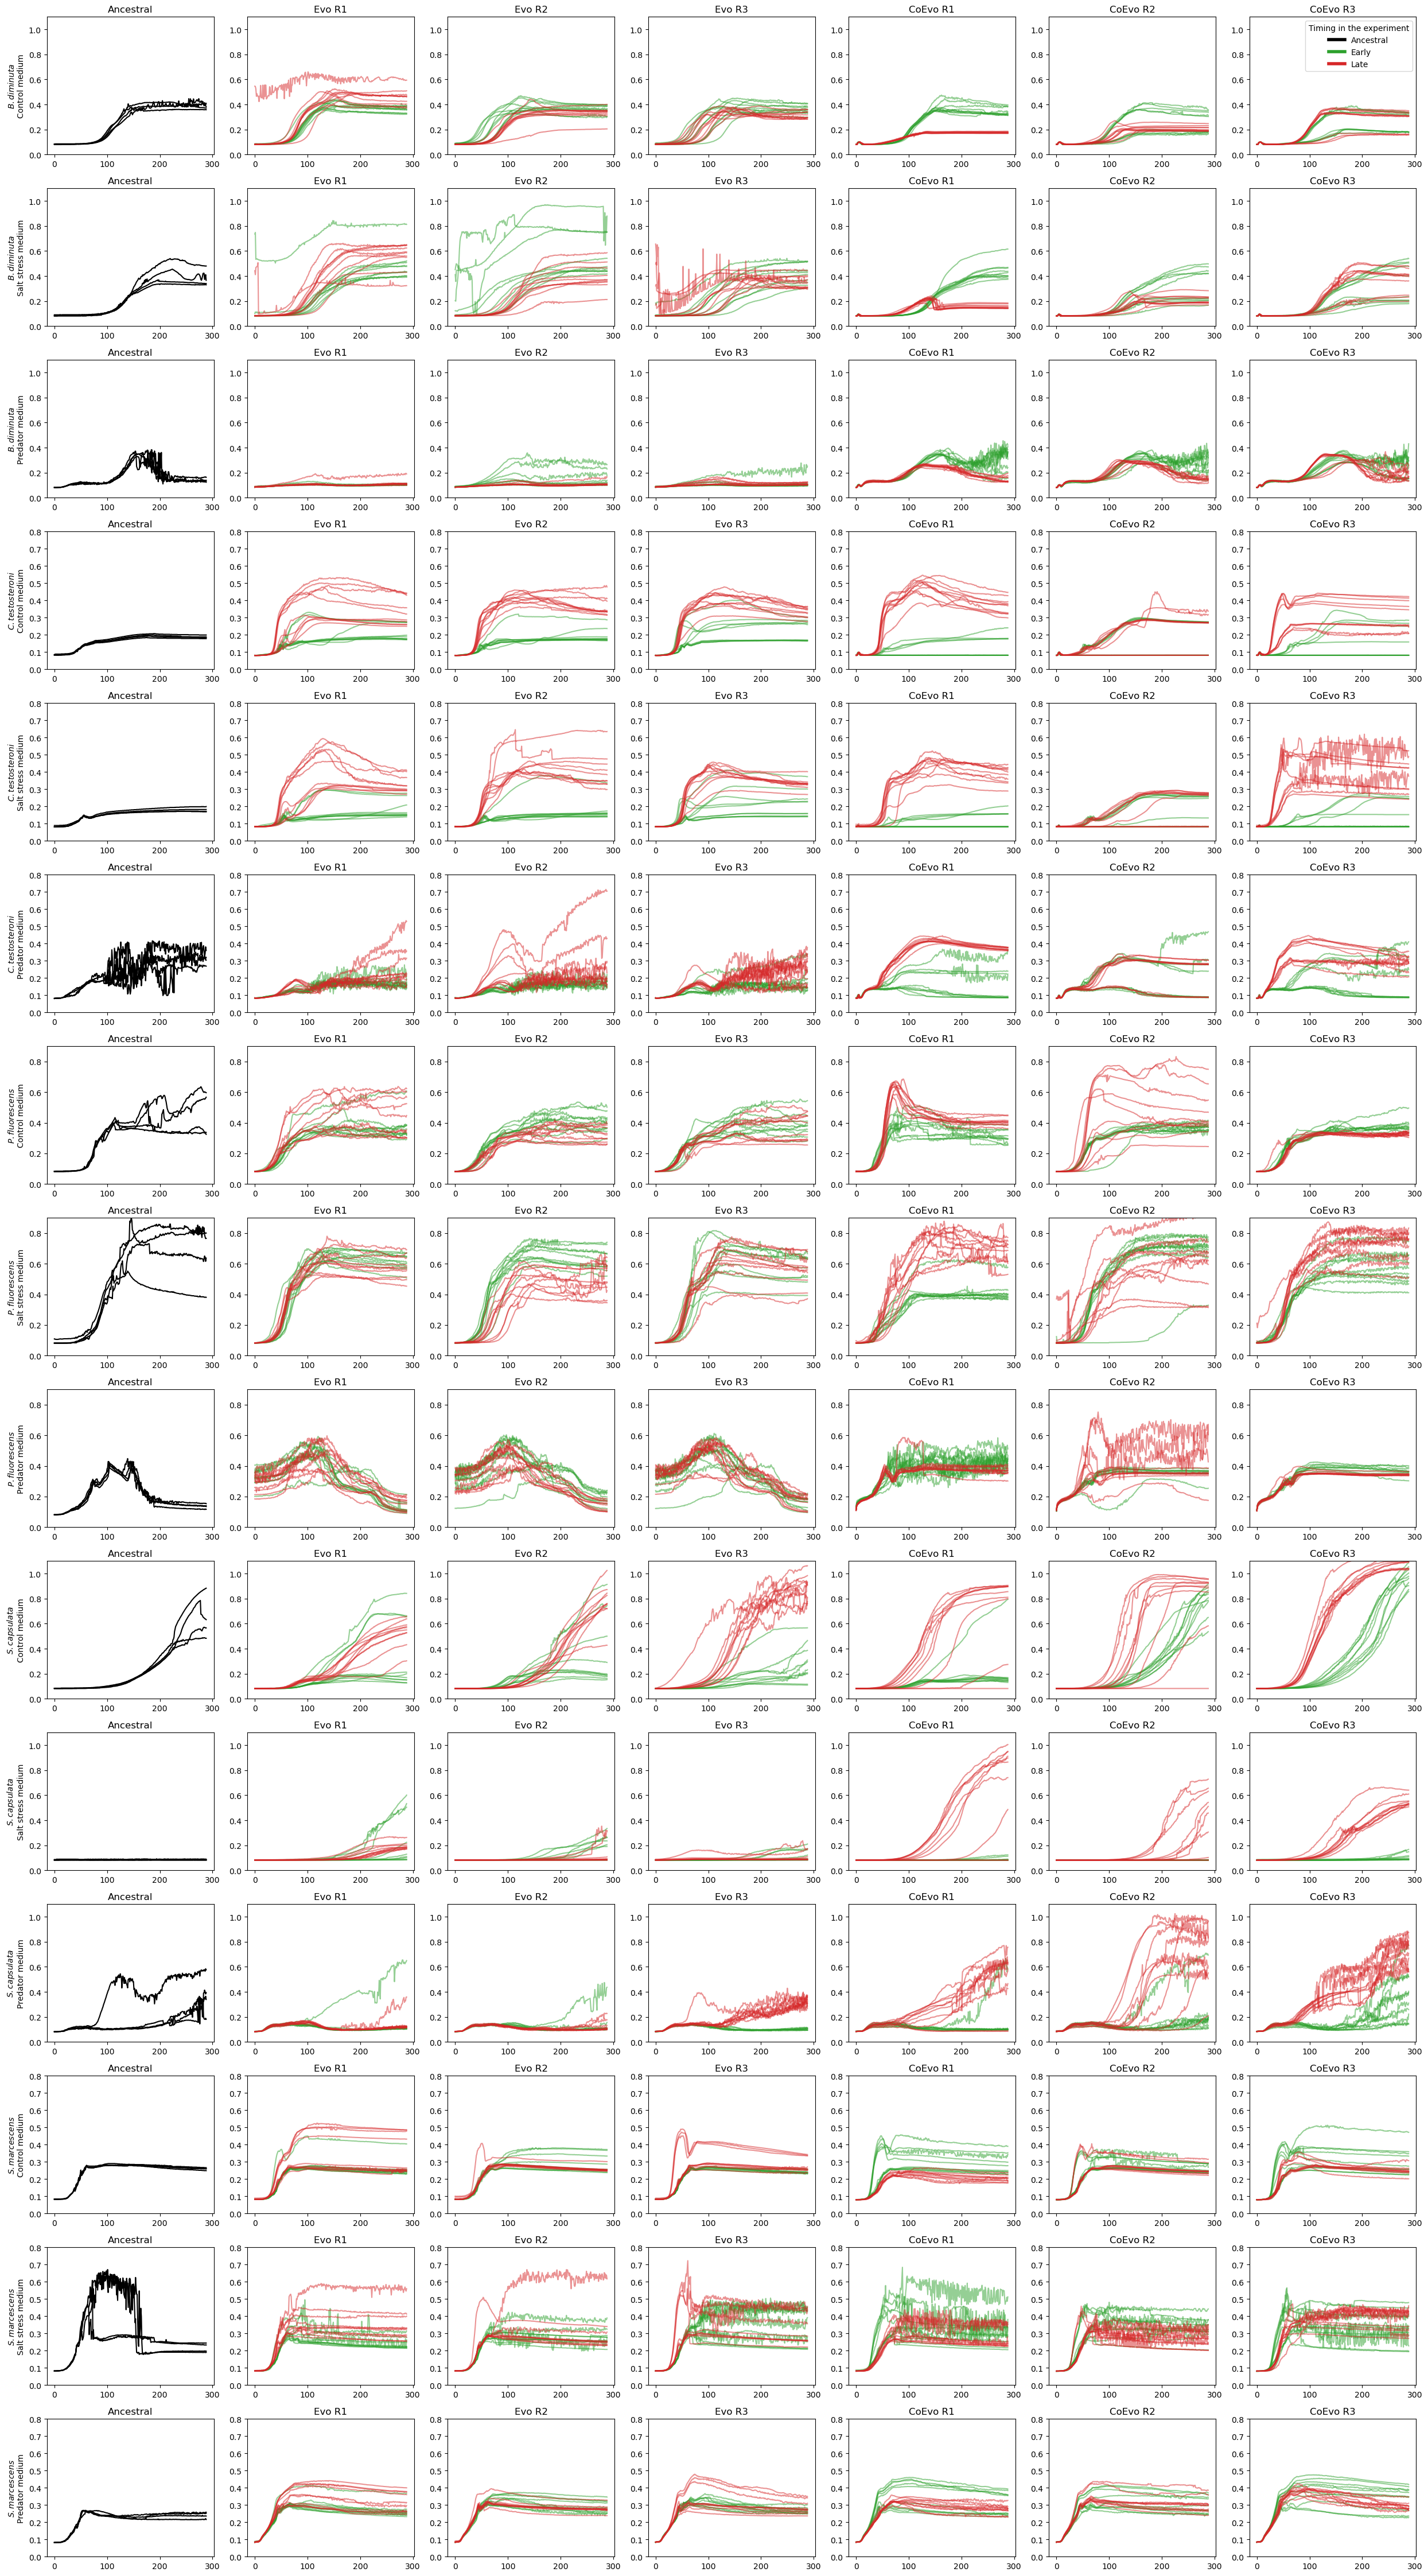

In [8]:
medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
medium_label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_medium_dict = {"KB": kb_anc_curves, "Tetra": tetra_anc_curves, "KCl": kcl_anc_curves}
anc_medium_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}

species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
medium_name_dict = {"KB": "Control medium", "KCl": "Salt stress medium", "Tetra": "Predator medium"}

species_list = ["BD", "CT", "PF", "SC", "SM"]
medium_list = ["KB", "KCl", "Tetra"]

ymax_species = {"BD": 1.1, "CT": 0.8, "PF": 0.9, "SC": 1.1, "SM": 0.8}

fig, axs = plt.subplots(15, 7, figsize=(25, 3*15))
c = 0
for i in range(len(species_list)):
    species = species_list[i]

    for j in range(len(medium_list)):
        medium = medium_list[j]
        labels = medium_label_dict[medium]
        evo_r1_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R1" and labels[i].split("_")[4] == "TP1"]
        evo_r1_tp1_curves = medium_dict[medium][evo_r1_tp1_idx]
        evo_r1_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R1" and labels[i].split("_")[4] == "TP2"]
        evo_r1_tp2_curves = medium_dict[medium][evo_r1_tp2_idx]
        evo_r2_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R2" and labels[i].split("_")[4] == "TP1"]
        evo_r2_tp1_curves = medium_dict[medium][evo_r2_tp1_idx]
        evo_r2_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R2" and labels[i].split("_")[4] == "TP2"]
        evo_r2_tp2_curves = medium_dict[medium][evo_r2_tp2_idx]
        evo_r3_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R3" and labels[i].split("_")[4] == "TP1"]
        evo_r3_tp1_curves = medium_dict[medium][evo_r3_tp1_idx]
        evo_r3_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "Evo" and labels[i].split("_")[3] == "R3" and labels[i].split("_")[4] == "TP2"]
        evo_r3_tp2_curves = medium_dict[medium][evo_r3_tp2_idx]
        
        coevo_r1_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R1" and labels[i].split("_")[4] == "TP1"]
        coevo_r1_tp1_curves = medium_dict[medium][coevo_r1_tp1_idx]
        coevo_r1_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R1" and labels[i].split("_")[4] == "TP2"]
        coevo_r1_tp2_curves = medium_dict[medium][coevo_r1_tp2_idx]
        coevo_r2_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R2" and labels[i].split("_")[4] == "TP1"]
        coevo_r2_tp1_curves = medium_dict[medium][coevo_r2_tp1_idx]
        coevo_r2_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R2" and labels[i].split("_")[4] == "TP2"]
        coevo_r2_tp2_curves = medium_dict[medium][coevo_r2_tp2_idx]
        coevo_r3_tp1_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R3" and labels[i].split("_")[4] == "TP1"]
        coevo_r3_tp1_curves = medium_dict[medium][coevo_r3_tp1_idx]
        coevo_r3_tp2_idx = [i for i in range(len(labels)) if labels[i].split("_")[0] == species and labels[i].split("_")[1] == "CoEvo" and labels[i].split("_")[3] == "R3" and labels[i].split("_")[4] == "TP2"]
        coevo_r3_tp2_curves = medium_dict[medium][coevo_r3_tp2_idx]

        anc_labels = anc_medium_label_dict[medium]
        anc_idx = [i for i in range(len(anc_labels)) if anc_labels[i].split("_")[0] == species]
        anc_curves = anc_medium_dict[medium][anc_idx]

        ymax = ymax_species[species]

        axs[c, 0].set_ylim(0, ymax)
        axs[c, 0].set_ylabel('$\it{' + species_name_dict[species] + "}$\n" + medium_name_dict[medium])
        axs[c, 0].set_title("Ancestral")
        for x in anc_curves:
            axs[c, 0].plot(x, color="black")

        axs[c, 1].set_ylim(0, ymax)
        axs[c, 1].set_title("Evo R1")
        for x in evo_r1_tp1_curves:
            axs[c, 1].plot(x, color="tab:green", alpha=0.5)
        
        for x in evo_r1_tp2_curves:
            axs[c, 1].plot(x, color="tab:red", alpha=0.5)

        axs[c, 2].set_ylim(0, ymax)
        axs[c, 2].set_title("Evo R2")
        for x in evo_r2_tp1_curves:
            axs[c, 2].plot(x, color="tab:green", alpha=0.5)
        
        for x in evo_r2_tp2_curves:
            axs[c, 2].plot(x, color="tab:red", alpha=0.5)

        axs[c, 3].set_ylim(0, ymax)
        axs[c, 3].set_title("Evo R3")
        for x in evo_r3_tp1_curves:
            axs[c, 3].plot(x, color="tab:green", alpha=0.5)
        
        for x in evo_r3_tp2_curves:
            axs[c, 3].plot(x, color="tab:red", alpha=0.5)

        axs[c, 4].set_ylim(0, ymax)
        axs[c, 4].set_title("CoEvo R1")
        for x in coevo_r1_tp1_curves:
            axs[c, 4].plot(x, color="tab:green", alpha=0.5)
        
        for x in coevo_r1_tp2_curves:
            axs[c, 4].plot(x, color="tab:red", alpha=0.5)

        axs[c, 5].set_ylim(0, ymax)
        axs[c, 5].set_title("CoEvo R2")
        for x in coevo_r2_tp1_curves:
            axs[c, 5].plot(x, color="tab:green", alpha=0.5)
        
        for x in coevo_r2_tp2_curves:
            axs[c, 5].plot(x, color="tab:red", alpha=0.5)

        axs[c, 6].set_ylim(0, ymax)
        axs[c, 6].set_title("CoEvo R3")
        for x in coevo_r3_tp1_curves:
            axs[c, 6].plot(x, color="tab:green", alpha=0.5)
        
        for x in coevo_r3_tp2_curves:
            axs[c, 6].plot(x, color="tab:red", alpha=0.5)

        c += 1


custom_legend = [Line2D([0], [0], lw=4, marker=None, color="black", label="Ancestral"),
                 Line2D([0], [0], lw=4, marker=None, color="tab:green", label="Early"),
                 Line2D([0], [0], lw=4, marker=None, color="tab:red", label="Late")]

axs[0, 6].legend(handles=custom_legend, title="Timing in the experiment")

plt.tight_layout()
# plt.savefig("growth_curves.png", dpi=200)
plt.show()

# Growth statistic boxplots

## Growth statistic boxplots with ancestor

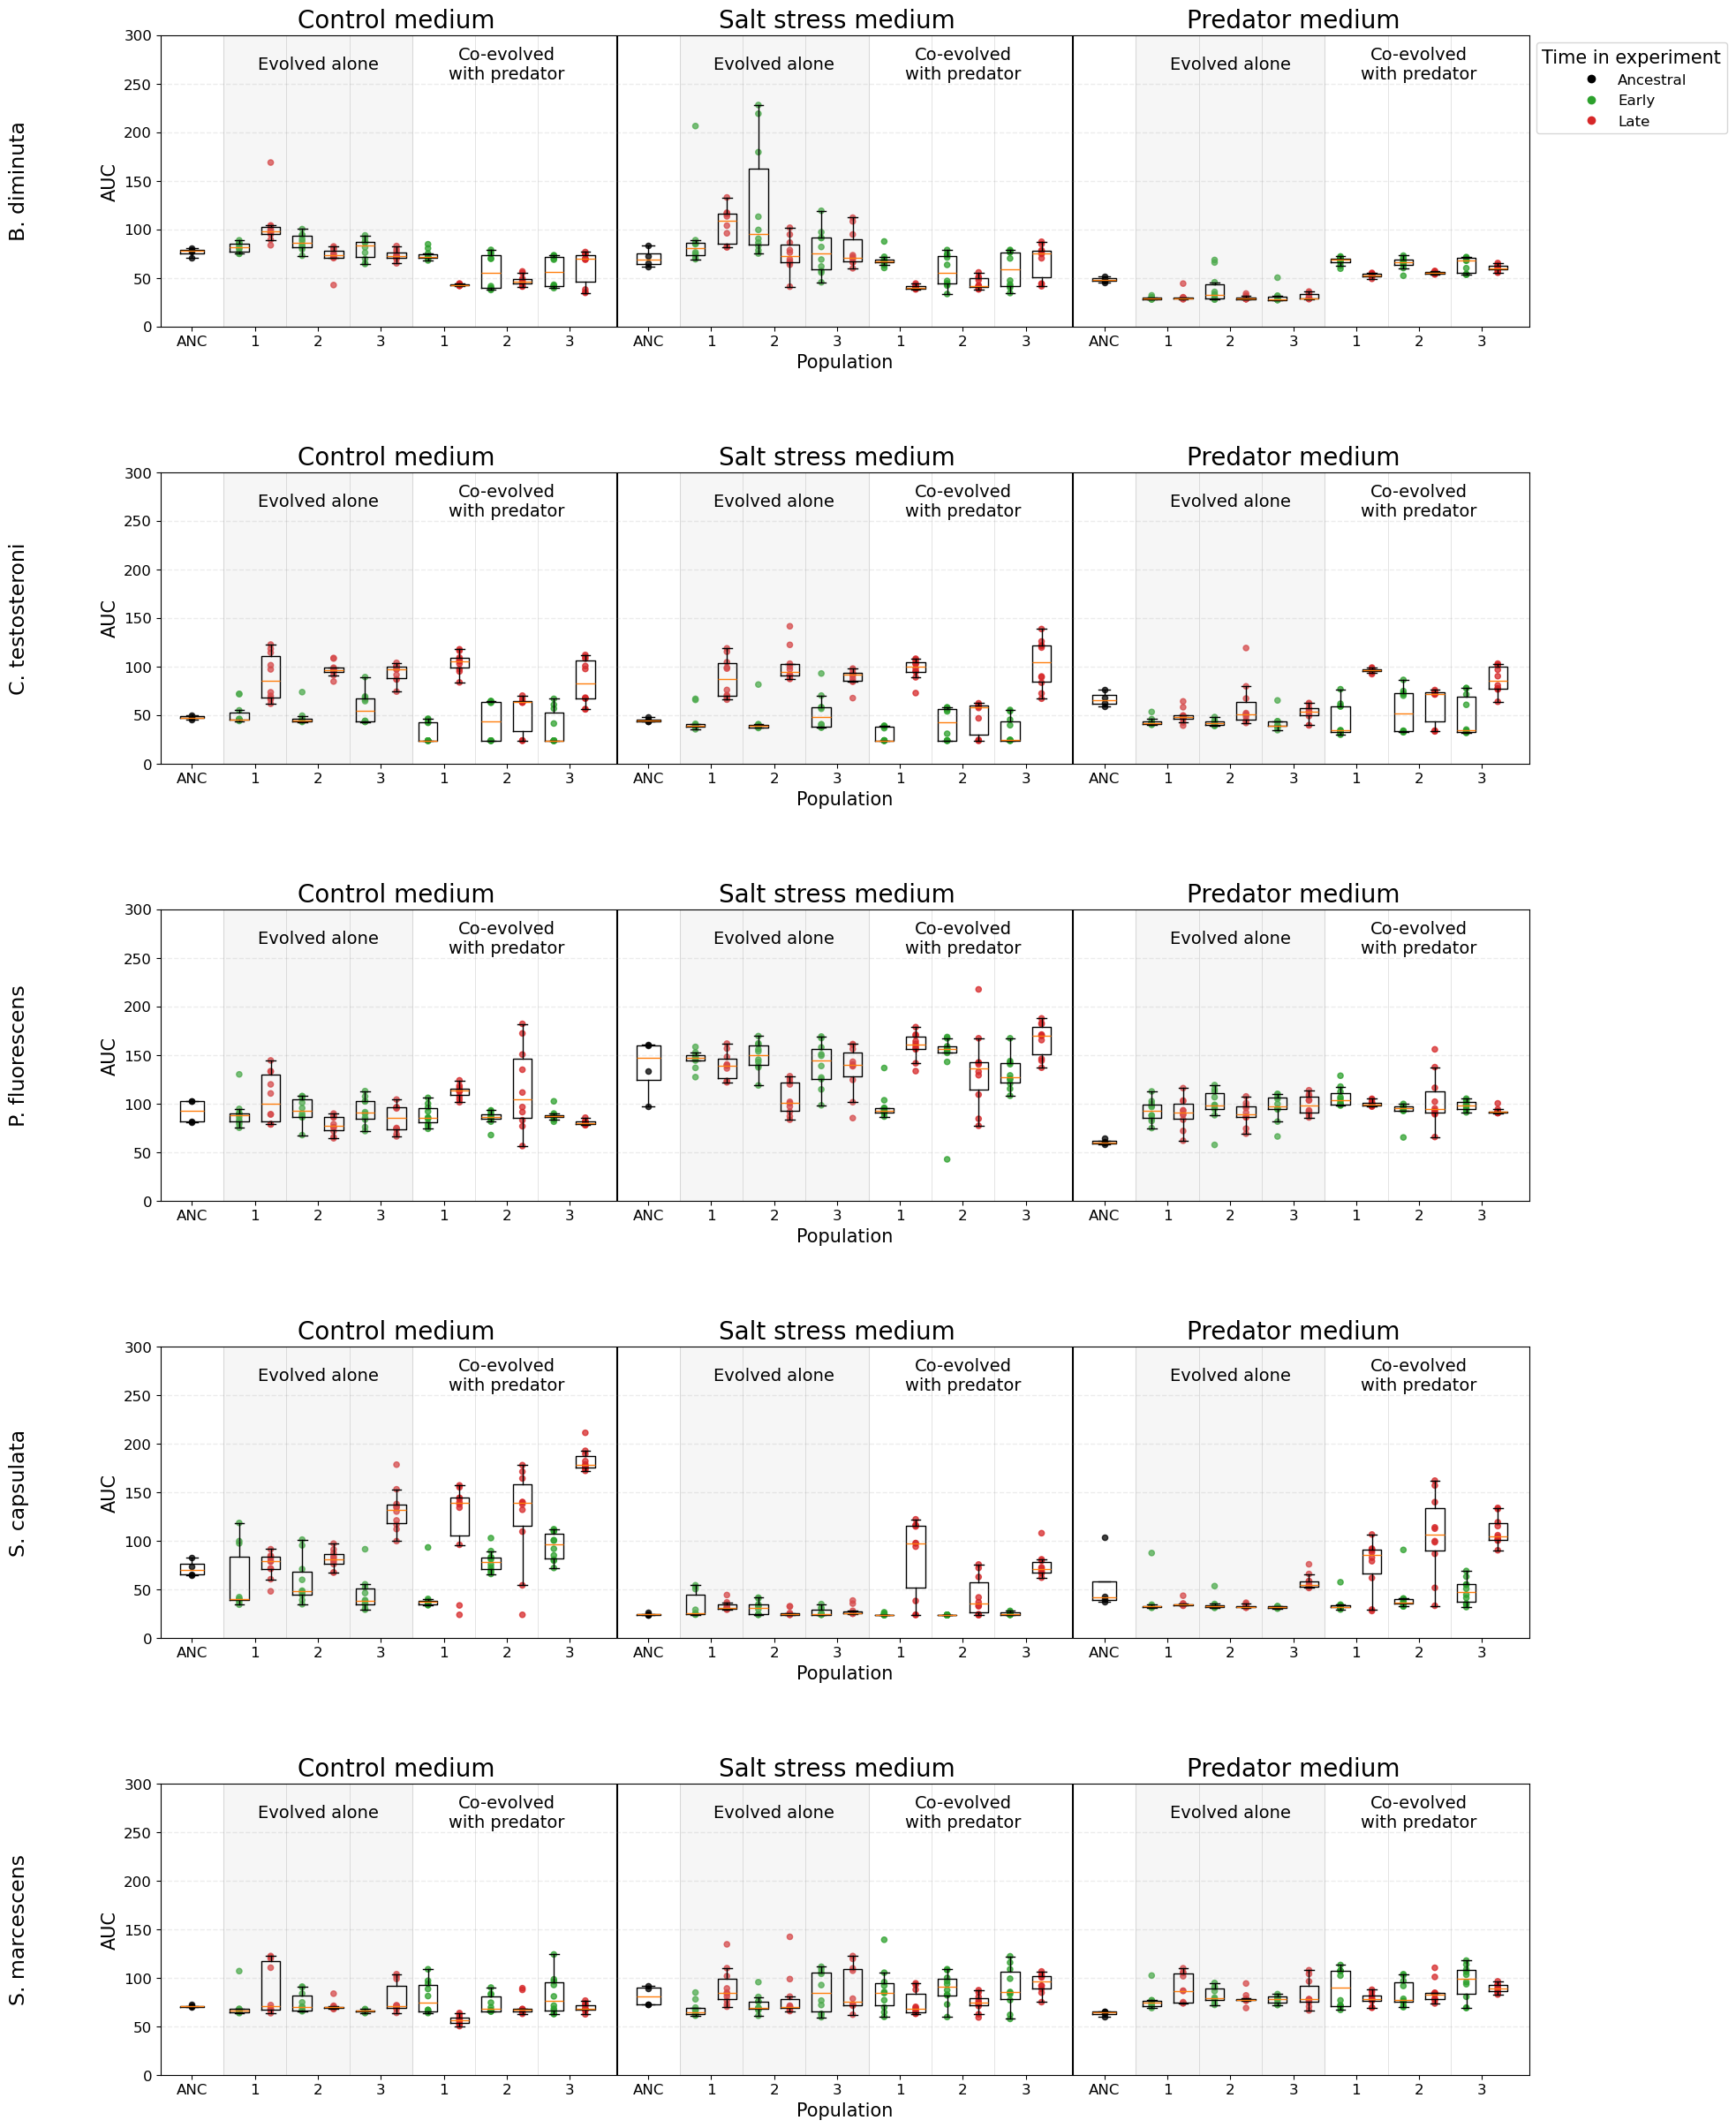

In [9]:
replicates = ["R1", "R2", "R3"]
tps = ["TP1", "TP2"]
colors = ["tab:green", "tab:orange", "tab:red"]
color_dict = {"TP1": "tab:green", "TP2": "tab:red"}
medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
anc_medium_dict = {"KB": kb_anc_curves, "Tetra": tetra_anc_curves, "KCl": kcl_anc_curves}
species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}
ymax_dict = {"BD": 300, "CT": 300, "PF": 300, "SC": 300, "SM": 300}

custom_lines = [Line2D([0], [0], lw=0, marker="o", color="black", label="Ancestral"),
                Line2D([0], [0], lw=0, marker="o", color="tab:green", label="Early"),
                Line2D([0], [0], lw=0, marker="o", color="tab:red", label="Late")]

box_stats_df = pd.DataFrame(columns=["Mean", "Median", "Variance"])
plt.subplots(5, 1, figsize=(20, 30))
si = 1
for species in ["BD", "CT", "PF", "SC", "SM"]:
    pos = 1.5
    plt.subplot(5, 1, si)
    for medium in ["KB", "KCl", "Tetra"]:
        medium_m = medium_dict[medium]
        anc_medium_m = anc_medium_dict[medium]
        labels = label_dict[medium]
        anc_labels = anc_label_dict[medium]

        ## Ancestral box
        select_anc_labels = np.unique(np.array([x for x in anc_labels if x.split("_")[0] == species]))
        idx = np.array([np.where(anc_labels == x)[0] for x in select_anc_labels]).flatten()
        
        anc_yields = anc_medium_m[idx, -1]
        anc_auc = np.sum(anc_medium_m[idx], axis=1)
        anc_rho_max = np.max(anc_medium_m[idx], axis=1)
        anc_t_rho_max = np.array([np.where(anc_medium_m[idx][i] == anc_rho_max[i])[0][0] for i in range(len(anc_rho_max))])
        anc_y = anc_auc
        
        plt.boxplot(anc_y, positions=[pos], widths=[0.75], showfliers=False)
        plt.scatter([pos]*len(anc_y), anc_y, c="black", alpha=0.75, s=20)
        pos += 1.5
        
        for hist in ["Evo", "CoEvo"]:
            for replicate in replicates:
                for tp in tps:
                    select_labels = np.unique(np.array([x for x in labels if (x.split("_")[0] == species and x.split("_")[1] == hist and x.split("_")[3] == replicate and x.split("_")[-1] == tp)]))
                    idx = np.array([np.where(labels == x)[0] for x in select_labels]).flatten()
                    scatter_colors = [color_dict[x.split("_")[-1]] for x in labels[idx]]
                    aucs = np.sum(medium_m[idx], axis=1)
                    yields = medium_m[idx, -1]
                    rho_max = np.max(medium_m[idx], axis=1)
                    t_rho_max = np.array([np.where(medium_m[idx][i] == rho_max[i])[0][0] for i in range(len(rho_max))])
                    y = aucs
                    
                    plt.boxplot(y, positions=[pos], widths=[0.6], showfliers=False)
                    plt.scatter([pos]*len(y), y, c=scatter_colors, alpha=0.75, s=20)

                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Mean"] = np.mean(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Median"] = np.median(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Variance"] = np.var(y)
                    
                    pos += 1
        pos += 1
    
    ymax = ymax_dict[species]
    plt.ylim(0, ymax)
    plt.ylabel("AUC", fontsize=15)
    plt.yticks(fontsize=12)
    plt.xlabel("Population", fontsize=15)
    
    xtick_labels = ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2

    plt.xticks(list(np.arange(1.5, 14, 2)) + list(np.arange(16, 28.5, 2)) + list(np.arange(30.5, 43, 2)), xtick_labels, fontsize=12)
    plt.xlim(0.5, 44)

    plt.vlines([2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 17, 19, 21, 23, 25, 27, 31.5, 33.5, 35.5, 37.5, 39.5, 41.5], 0, ymax, color="black", alpha=0.15, lw=0.5)
    plt.vlines([15, 29.5], 0, ymax, color="black")
    
    plt.axvspan(2.5, 8.5, alpha=0.2, color="lightgray")
    plt.axvspan(17, 23, alpha=0.2, color="lightgray")
    plt.axvspan(31.5, 37.5, alpha=0.2, color="lightgray")

    plt.hlines(plt.gca().get_yticks()[1:-1], 0.5, 44, alpha=0.15, color="gray", linestyle="dashed", lw=1)

    plt.text(5.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(11.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(20, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(26, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(34.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(40.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(8, ymax+ymax*0.05, "Control medium", va="center", ha="center", fontsize=20)
    plt.text(22, ymax+ymax*0.05, "Salt stress medium", va="center", ha="center", fontsize=20)
    plt.text(36.5, ymax+ymax*0.05, "Predator medium", va="center", ha="center", fontsize=20)
    
    plt.text(-4, ymax/2, species_name_dict[species], va="center", ha="center", fontsize=17, rotation=90)
    

    if si == 1:
        plt.legend(handles=custom_lines, title="Time in experiment", fontsize=12, title_fontsize=15, bbox_to_anchor=(1.15, 1), loc="upper right")

    si += 1 

# plt.savefig("./auc_boxplot.svg", dpi=200, bbox_inches="tight")
plt.subplots_adjust(hspace=0.5)
plt.show()

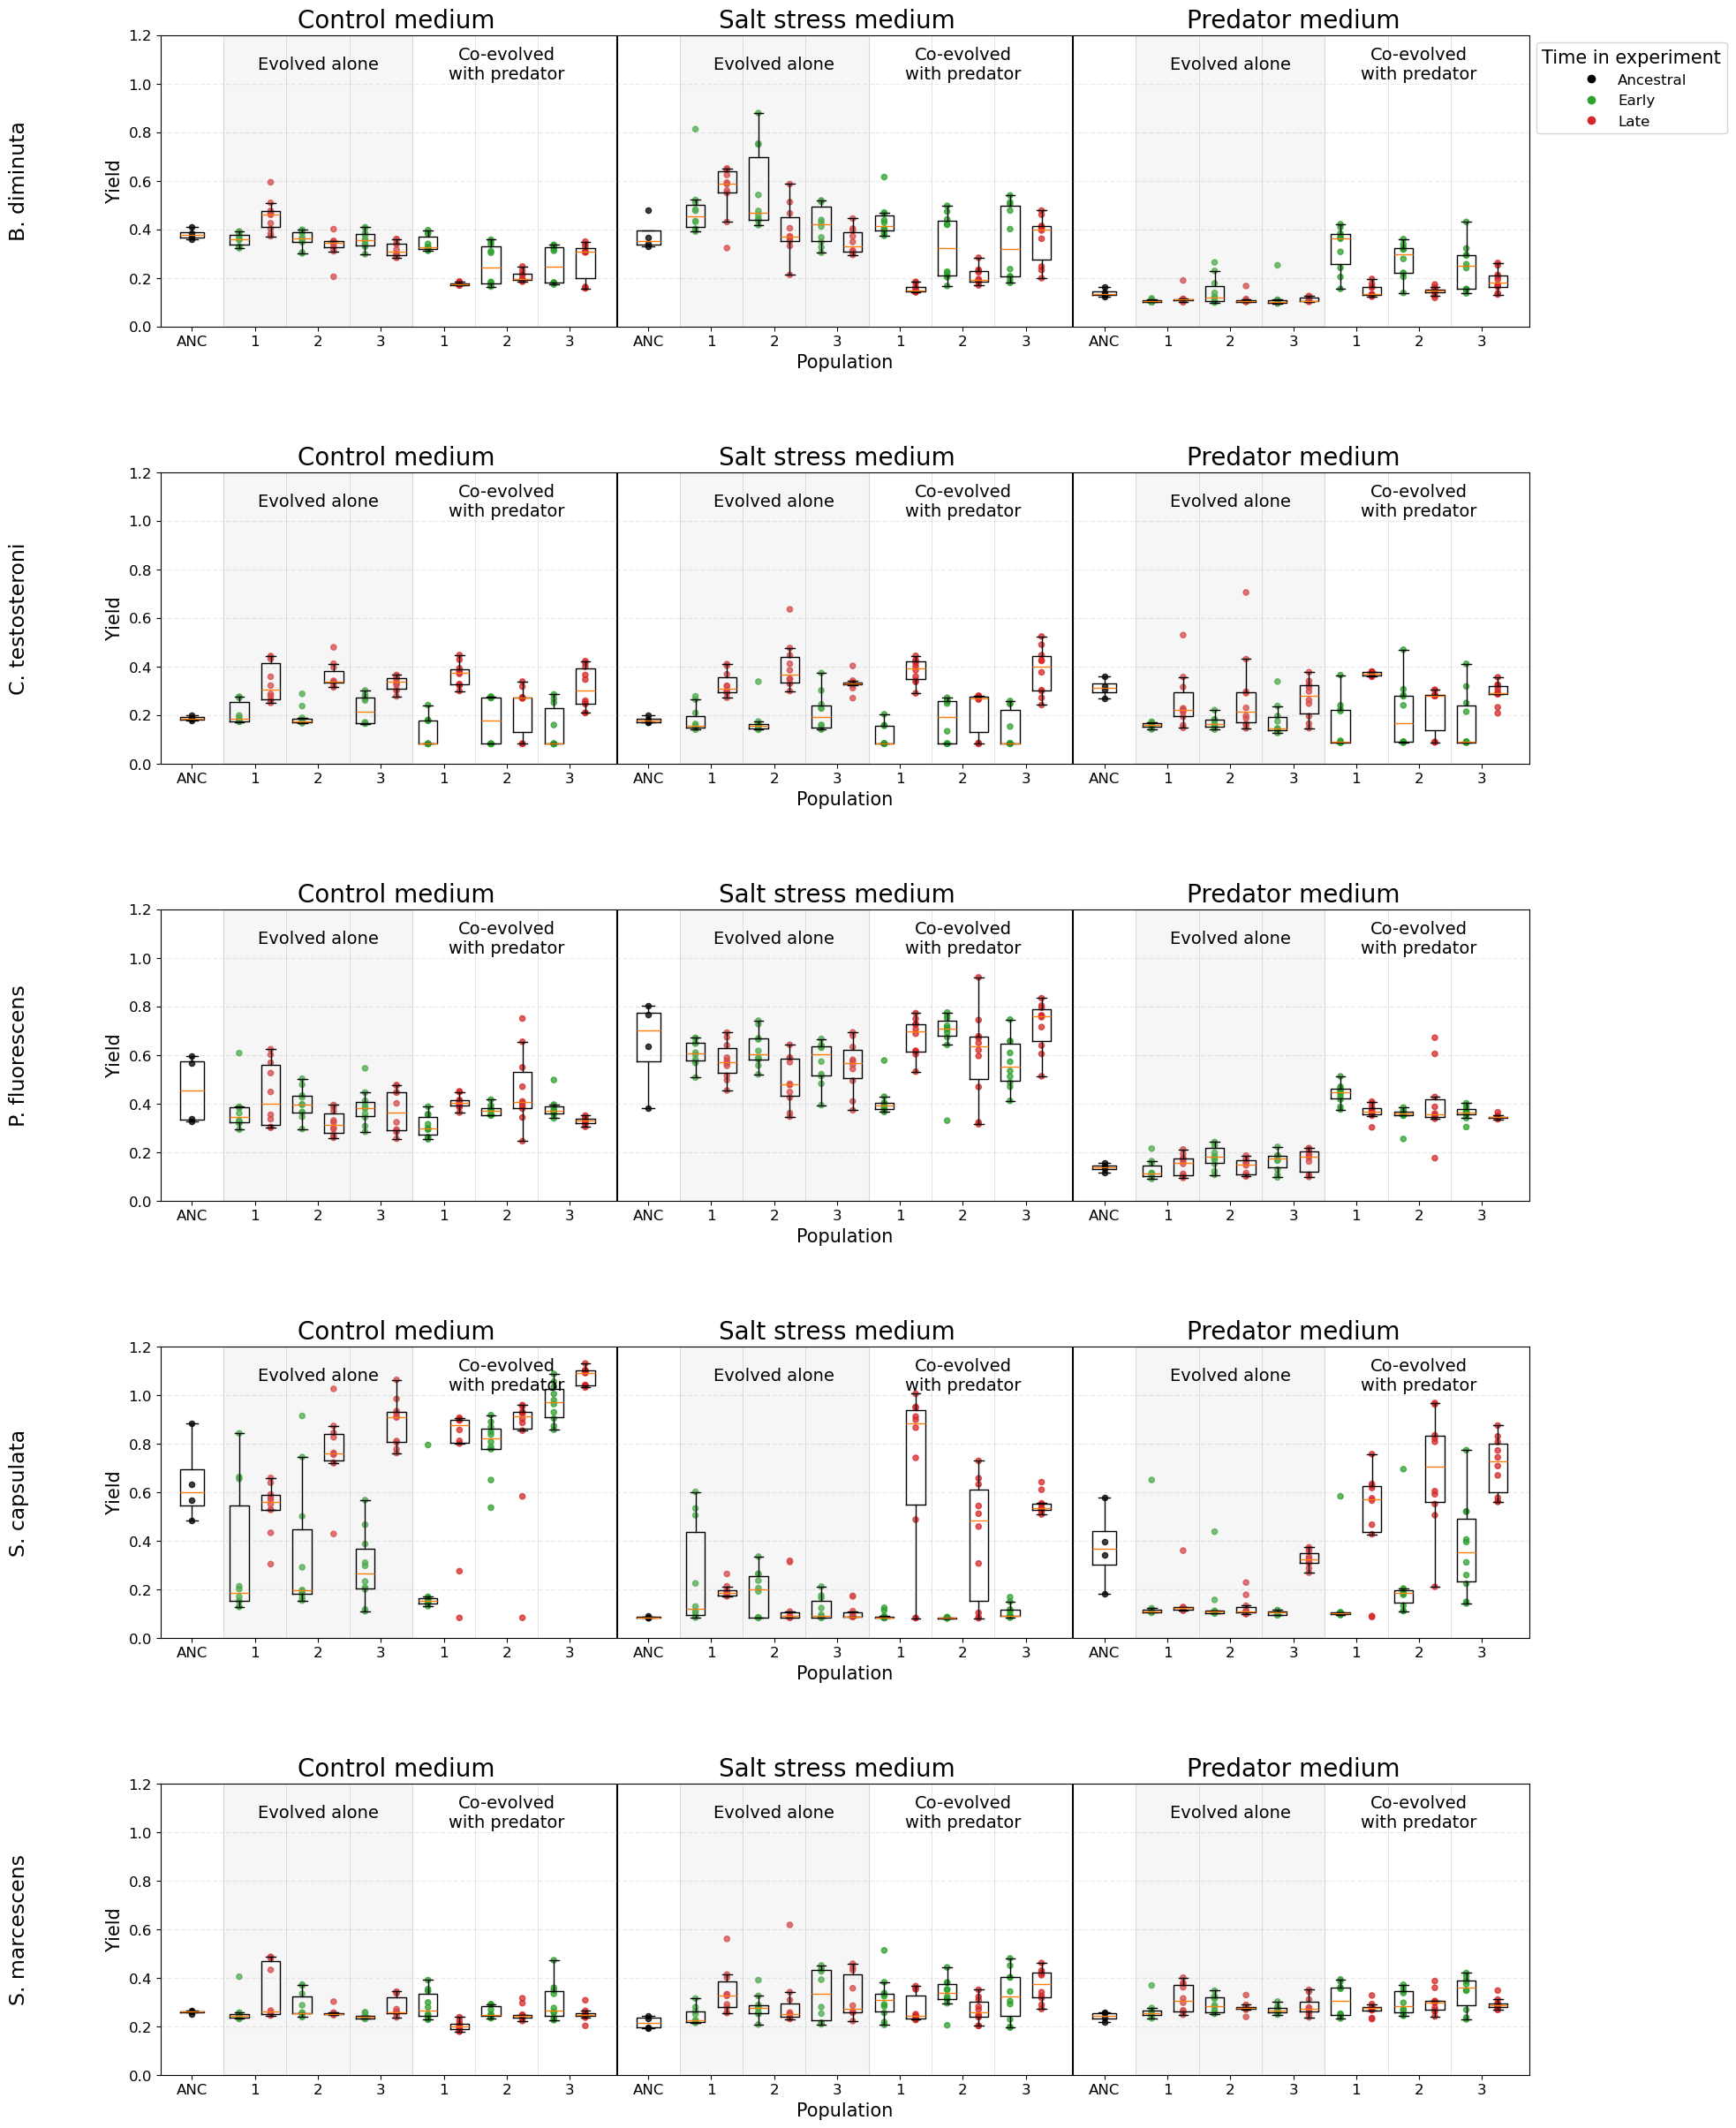

In [10]:
replicates = ["R1", "R2", "R3"]
tps = ["TP1", "TP2"]
colors = ["tab:green", "tab:orange", "tab:red"]
color_dict = {"TP1": "tab:green", "TP2": "tab:red"}
medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
anc_medium_dict = {"KB": kb_anc_curves, "Tetra": tetra_anc_curves, "KCl": kcl_anc_curves}
species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}
ymax_dict = {"BD": 1.2, "CT": 1.2, "PF": 1.2, "SC": 1.2, "SM": 1.2}

custom_lines = [Line2D([0], [0], lw=0, marker="o", color="black", label="Ancestral"),
                Line2D([0], [0], lw=0, marker="o", color="tab:green", label="Early"),
                Line2D([0], [0], lw=0, marker="o", color="tab:red", label="Late")]

box_stats_df = pd.DataFrame(columns=["Mean", "Median", "Variance"])
plt.subplots(5, 1, figsize=(20, 30))
si = 1
for species in ["BD", "CT", "PF", "SC", "SM"]:
    pos = 1.5
    plt.subplot(5, 1, si)
    for medium in ["KB", "KCl", "Tetra"]:
        medium_m = medium_dict[medium]
        anc_medium_m = anc_medium_dict[medium]
        labels = label_dict[medium]
        anc_labels = anc_label_dict[medium]

        ## Ancestral box
        select_anc_labels = np.unique(np.array([x for x in anc_labels if x.split("_")[0] == species]))
        idx = np.array([np.where(anc_labels == x)[0] for x in select_anc_labels]).flatten()
        
        anc_yields = anc_medium_m[idx, -1]
        anc_auc = np.sum(anc_medium_m[idx], axis=1)
        anc_rho_max = np.max(anc_medium_m[idx], axis=1)
        anc_t_rho_max = np.array([np.where(anc_medium_m[idx][i] == anc_rho_max[i])[0][0] for i in range(len(anc_rho_max))])
        anc_y = anc_yields
        
        plt.boxplot(anc_y, positions=[pos], widths=[0.75], showfliers=False)
        plt.scatter([pos]*len(anc_y), anc_y, c="black", alpha=0.75, s=20)
        pos += 1.5
        
        for hist in ["Evo", "CoEvo"]:
            for replicate in replicates:
                for tp in tps:
                    select_labels = np.unique(np.array([x for x in labels if (x.split("_")[0] == species and x.split("_")[1] == hist and x.split("_")[3] == replicate and x.split("_")[-1] == tp)]))
                    idx = np.array([np.where(labels == x)[0] for x in select_labels]).flatten()
                    scatter_colors = [color_dict[x.split("_")[-1]] for x in labels[idx]]
                    aucs = np.sum(medium_m[idx], axis=1)
                    yields = medium_m[idx, -1]
                    rho_max = np.max(medium_m[idx], axis=1)
                    t_rho_max = np.array([np.where(medium_m[idx][i] == rho_max[i])[0][0] for i in range(len(rho_max))])
                    y = yields
                    
                    plt.boxplot(y, positions=[pos], widths=[0.6], showfliers=False)
                    plt.scatter([pos]*len(y), y, c=scatter_colors, alpha=0.75, s=20)

                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Mean"] = np.mean(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Median"] = np.median(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Variance"] = np.var(y)
                    
                    pos += 1
        pos += 1
    
    ymax = ymax_dict[species]
    plt.ylim(0, ymax)
    plt.ylabel("Yield", fontsize=15)
    plt.yticks(fontsize=12)
    plt.xlabel("Population", fontsize=15)
    
    xtick_labels = ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2

    plt.xticks(list(np.arange(1.5, 14, 2)) + list(np.arange(16, 28.5, 2)) + list(np.arange(30.5, 43, 2)), xtick_labels, fontsize=12)
    plt.xlim(0.5, 44)

    plt.vlines([2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 17, 19, 21, 23, 25, 27, 31.5, 33.5, 35.5, 37.5, 39.5, 41.5], 0, ymax, color="black", alpha=0.15, lw=0.5)
    plt.vlines([15, 29.5], 0, ymax, color="black")
    
    plt.axvspan(2.5, 8.5, alpha=0.2, color="lightgray")
    plt.axvspan(17, 23, alpha=0.2, color="lightgray")
    plt.axvspan(31.5, 37.5, alpha=0.2, color="lightgray")

    plt.hlines(plt.gca().get_yticks()[1:-1], 0.5, 44, alpha=0.15, color="gray", linestyle="dashed", lw=1)

    plt.text(5.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(11.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(20, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(26, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(34.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(40.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(8, ymax+ymax*0.05, "Control medium", va="center", ha="center", fontsize=20)
    plt.text(22, ymax+ymax*0.05, "Salt stress medium", va="center", ha="center", fontsize=20)
    plt.text(36.5, ymax+ymax*0.05, "Predator medium", va="center", ha="center", fontsize=20)
    
    plt.text(-4, ymax/2, species_name_dict[species], va="center", ha="center", fontsize=17, rotation=90)
    

    if si == 1:
        plt.legend(handles=custom_lines, title="Time in experiment", fontsize=12, title_fontsize=15, bbox_to_anchor=(1.15, 1), loc="upper right")

    si += 1 

# plt.savefig("./yield_boxplot.svg", dpi=200, bbox_inches="tight")
plt.subplots_adjust(hspace=0.5)
plt.show()

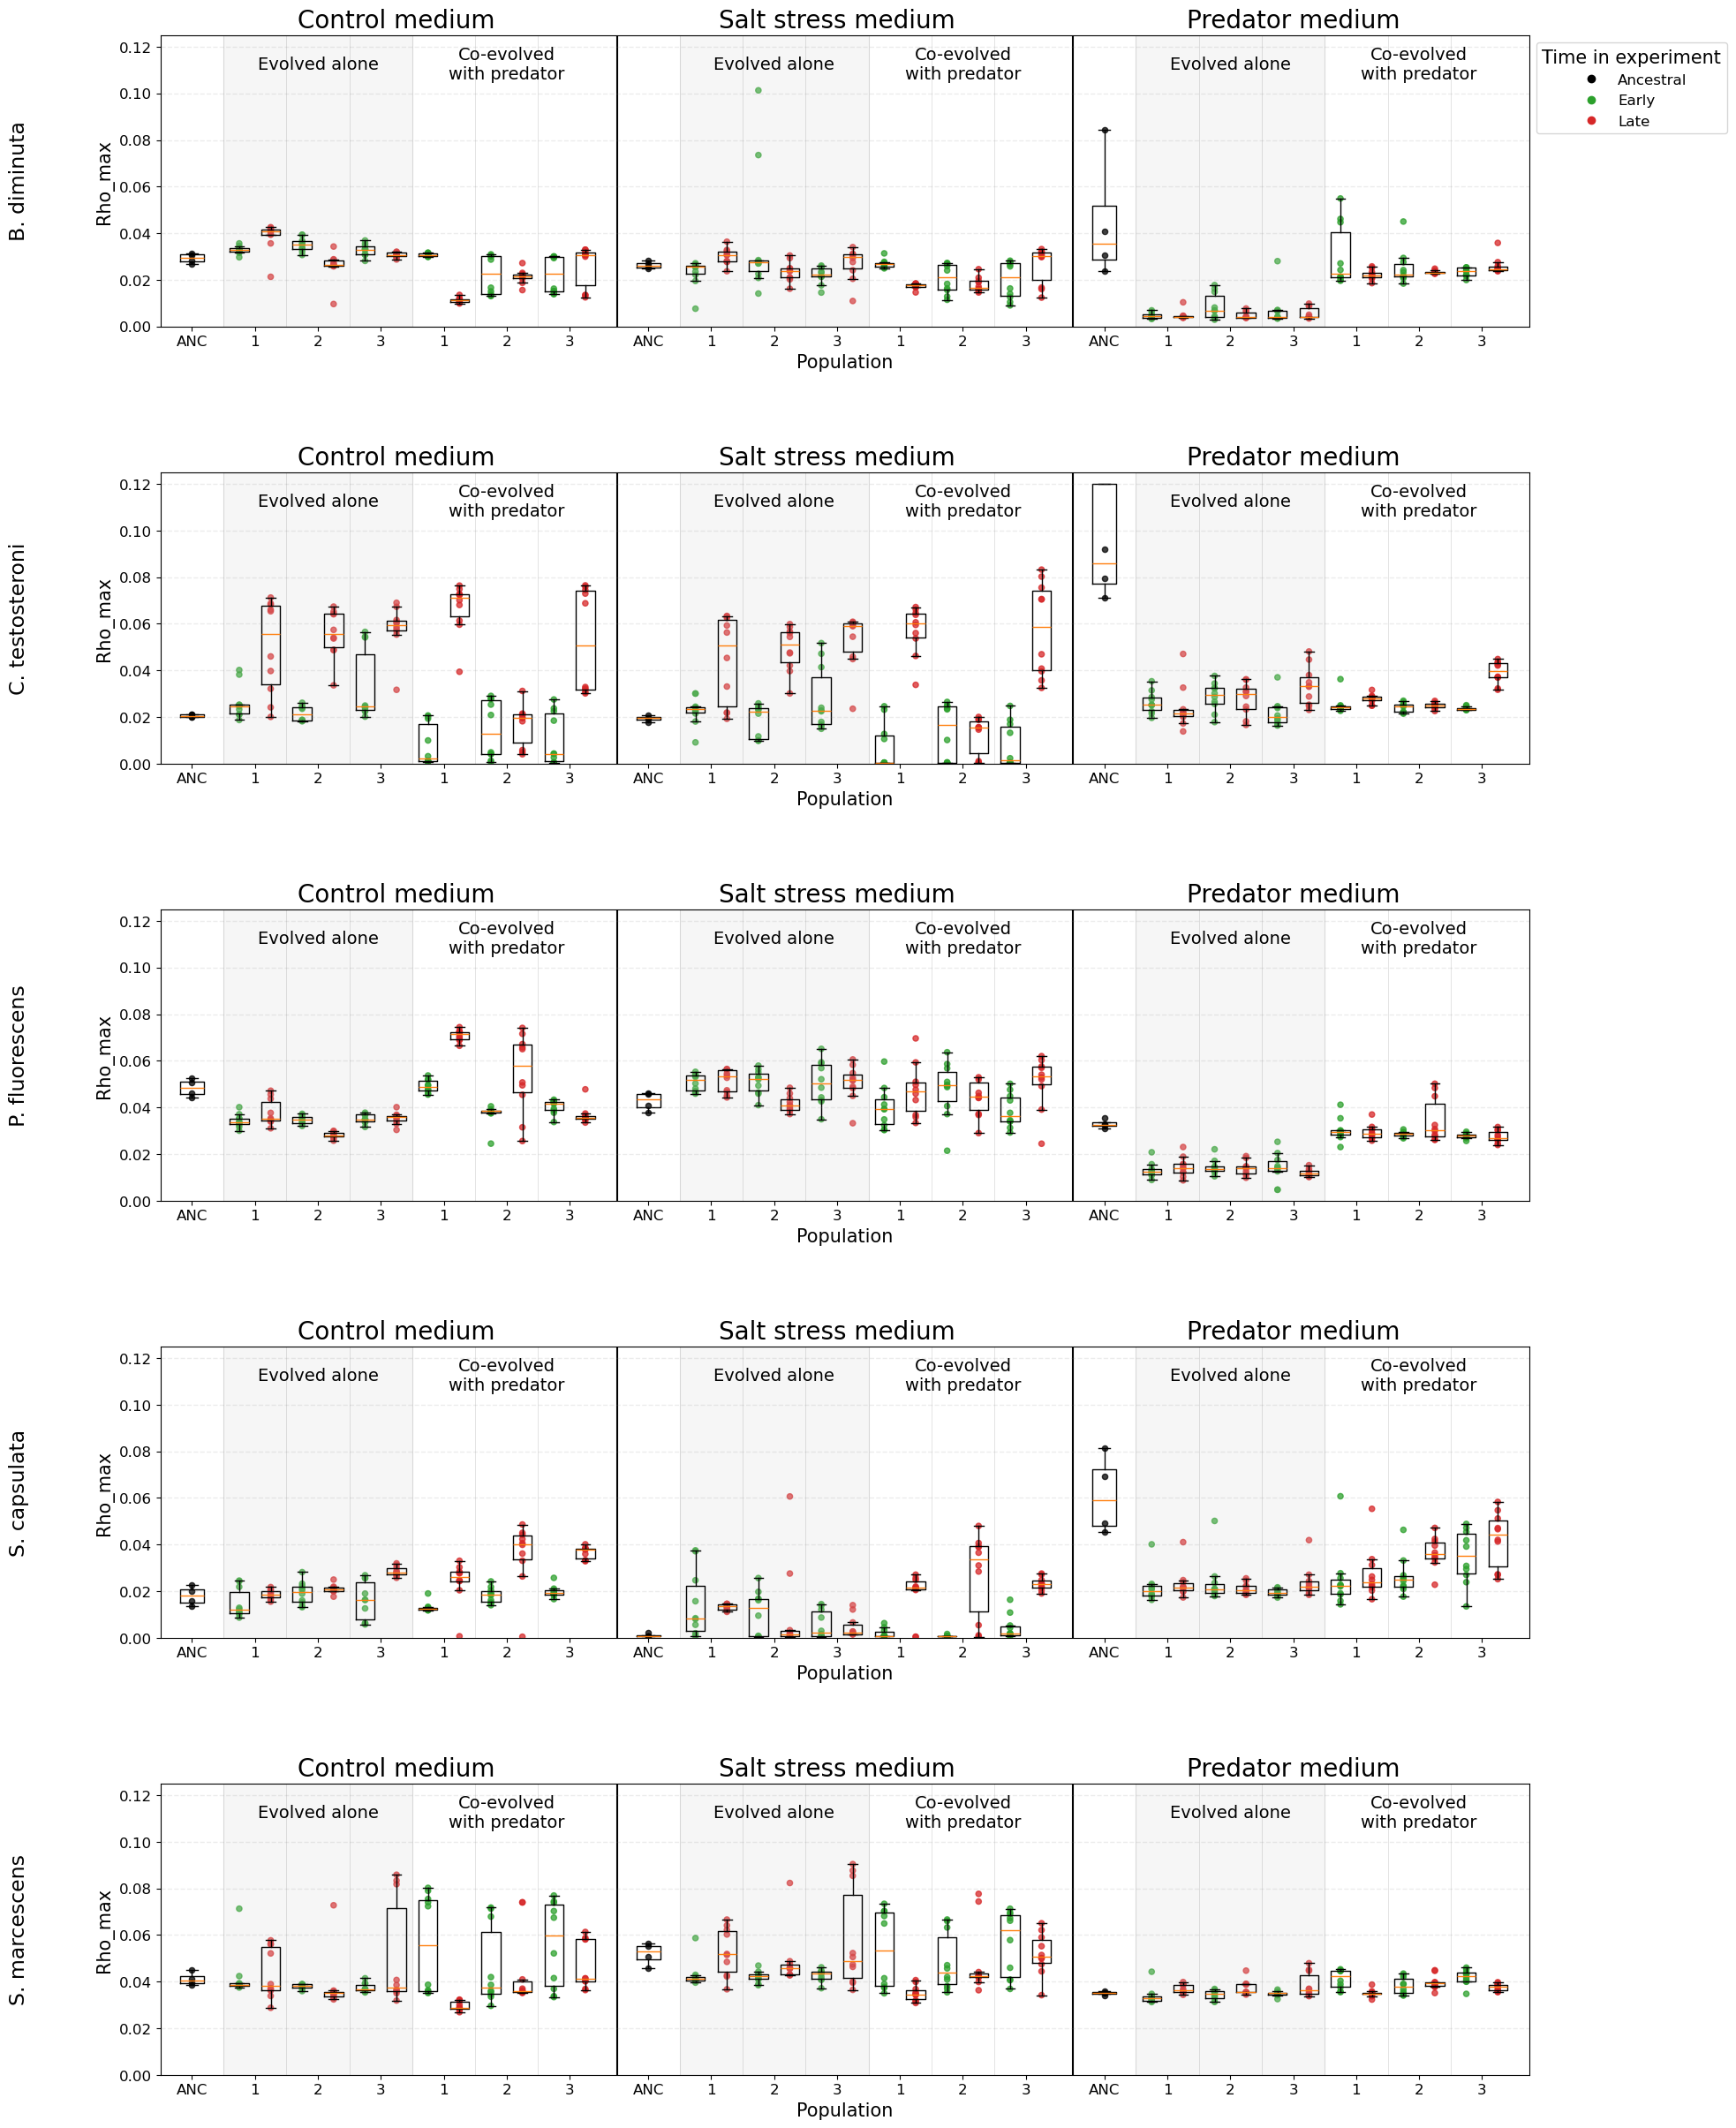

In [11]:
replicates = ["R1", "R2", "R3"]
tps = ["TP1", "TP2"]
colors = ["tab:green", "tab:orange", "tab:red"]
color_dict = {"TP1": "tab:green", "TP2": "tab:red"}
medium_dict = {"KB": kb_m_gr, "Tetra": tetra_m_gr, "KCl": kcl_m_gr}
anc_medium_dict = {"KB": kb_anc_gr, "Tetra": tetra_anc_gr, "KCl": kcl_anc_gr}
species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}
ymax_dict = {"BD": 0.125, "CT": 0.125, "PF": 0.125, "SC": 0.125, "SM": 0.125}

custom_lines = [Line2D([0], [0], lw=0, marker="o", color="black", label="Ancestral"),
                Line2D([0], [0], lw=0, marker="o", color="tab:green", label="Early"),
                Line2D([0], [0], lw=0, marker="o", color="tab:red", label="Late")]

box_stats_df = pd.DataFrame(columns=["Mean", "Median", "Variance"])
plt.subplots(5, 1, figsize=(20, 30))
si = 1
for species in ["BD", "CT", "PF", "SC", "SM"]:
    pos = 1.5
    plt.subplot(5, 1, si)
    for medium in ["KB", "KCl", "Tetra"]:
        medium_m = medium_dict[medium]
        anc_medium_m = anc_medium_dict[medium]
        labels = label_dict[medium]
        anc_labels = anc_label_dict[medium]

        ## Ancestral box
        select_anc_labels = np.unique(np.array([x for x in anc_labels if x.split("_")[0] == species]))
        idx = np.array([np.where(anc_labels == x)[0] for x in select_anc_labels]).flatten()
        
        anc_yields = anc_medium_m[idx, -1]
        anc_auc = np.sum(anc_medium_m[idx], axis=1)
        anc_rho_max = np.max(anc_medium_m[idx], axis=1)
        anc_t_rho_max = np.array([np.where(anc_medium_m[idx][i] == anc_rho_max[i])[0][0] for i in range(len(anc_rho_max))])
        anc_y = anc_rho_max
        
        plt.boxplot(anc_y, positions=[pos], widths=[0.75], showfliers=False)
        plt.scatter([pos]*len(anc_y), anc_y, c="black", alpha=0.75, s=20)
        pos += 1.5
        
        for hist in ["Evo", "CoEvo"]:
            for replicate in replicates:
                for tp in tps:
                    select_labels = np.unique(np.array([x for x in labels if (x.split("_")[0] == species and x.split("_")[1] == hist and x.split("_")[3] == replicate and x.split("_")[-1] == tp)]))
                    idx = np.array([np.where(labels == x)[0] for x in select_labels]).flatten()
                    scatter_colors = [color_dict[x.split("_")[-1]] for x in labels[idx]]
                    aucs = np.sum(medium_m[idx], axis=1)
                    yields = medium_m[idx, -1]
                    rho_max = np.max(medium_m[idx], axis=1)
                    t_rho_max = np.array([np.where(medium_m[idx][i] == rho_max[i])[0][0] for i in range(len(rho_max))])
                    y = rho_max
                    
                    plt.boxplot(y, positions=[pos], widths=[0.6], showfliers=False)
                    plt.scatter([pos]*len(y), y, c=scatter_colors, alpha=0.75, s=20)

                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Mean"] = np.mean(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Median"] = np.median(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Variance"] = np.var(y)
                    
                    pos += 1
        pos += 1
    
    ymax = ymax_dict[species]
    plt.ylim(0, ymax)
    plt.ylabel("Rho_max", fontsize=15)
    plt.yticks(fontsize=12)
    plt.xlabel("Population", fontsize=15)
    
    xtick_labels = ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2

    plt.xticks(list(np.arange(1.5, 14, 2)) + list(np.arange(16, 28.5, 2)) + list(np.arange(30.5, 43, 2)), xtick_labels, fontsize=12)
    plt.xlim(0.5, 44)

    plt.vlines([2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 17, 19, 21, 23, 25, 27, 31.5, 33.5, 35.5, 37.5, 39.5, 41.5], 0, ymax, color="black", alpha=0.15, lw=0.5)
    plt.vlines([15, 29.5], 0, ymax, color="black")
    
    plt.axvspan(2.5, 8.5, alpha=0.2, color="lightgray")
    plt.axvspan(17, 23, alpha=0.2, color="lightgray")
    plt.axvspan(31.5, 37.5, alpha=0.2, color="lightgray")

    plt.hlines(plt.gca().get_yticks()[1:-1], 0.5, 44, alpha=0.15, color="gray", linestyle="dashed", lw=1)

    plt.text(5.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(11.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(20, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(26, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(34.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(40.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(8, ymax+ymax*0.05, "Control medium", va="center", ha="center", fontsize=20)
    plt.text(22, ymax+ymax*0.05, "Salt stress medium", va="center", ha="center", fontsize=20)
    plt.text(36.5, ymax+ymax*0.05, "Predator medium", va="center", ha="center", fontsize=20)
    
    plt.text(-4, ymax/2, species_name_dict[species], va="center", ha="center", fontsize=17, rotation=90)
    

    if si == 1:
        plt.legend(handles=custom_lines, title="Time in experiment", fontsize=12, title_fontsize=15, bbox_to_anchor=(1.15, 1), loc="upper right")

    si += 1 

# plt.savefig("./rho_max_boxplot.svg", dpi=200, bbox_inches="tight")
plt.subplots_adjust(hspace=0.5)
plt.show()

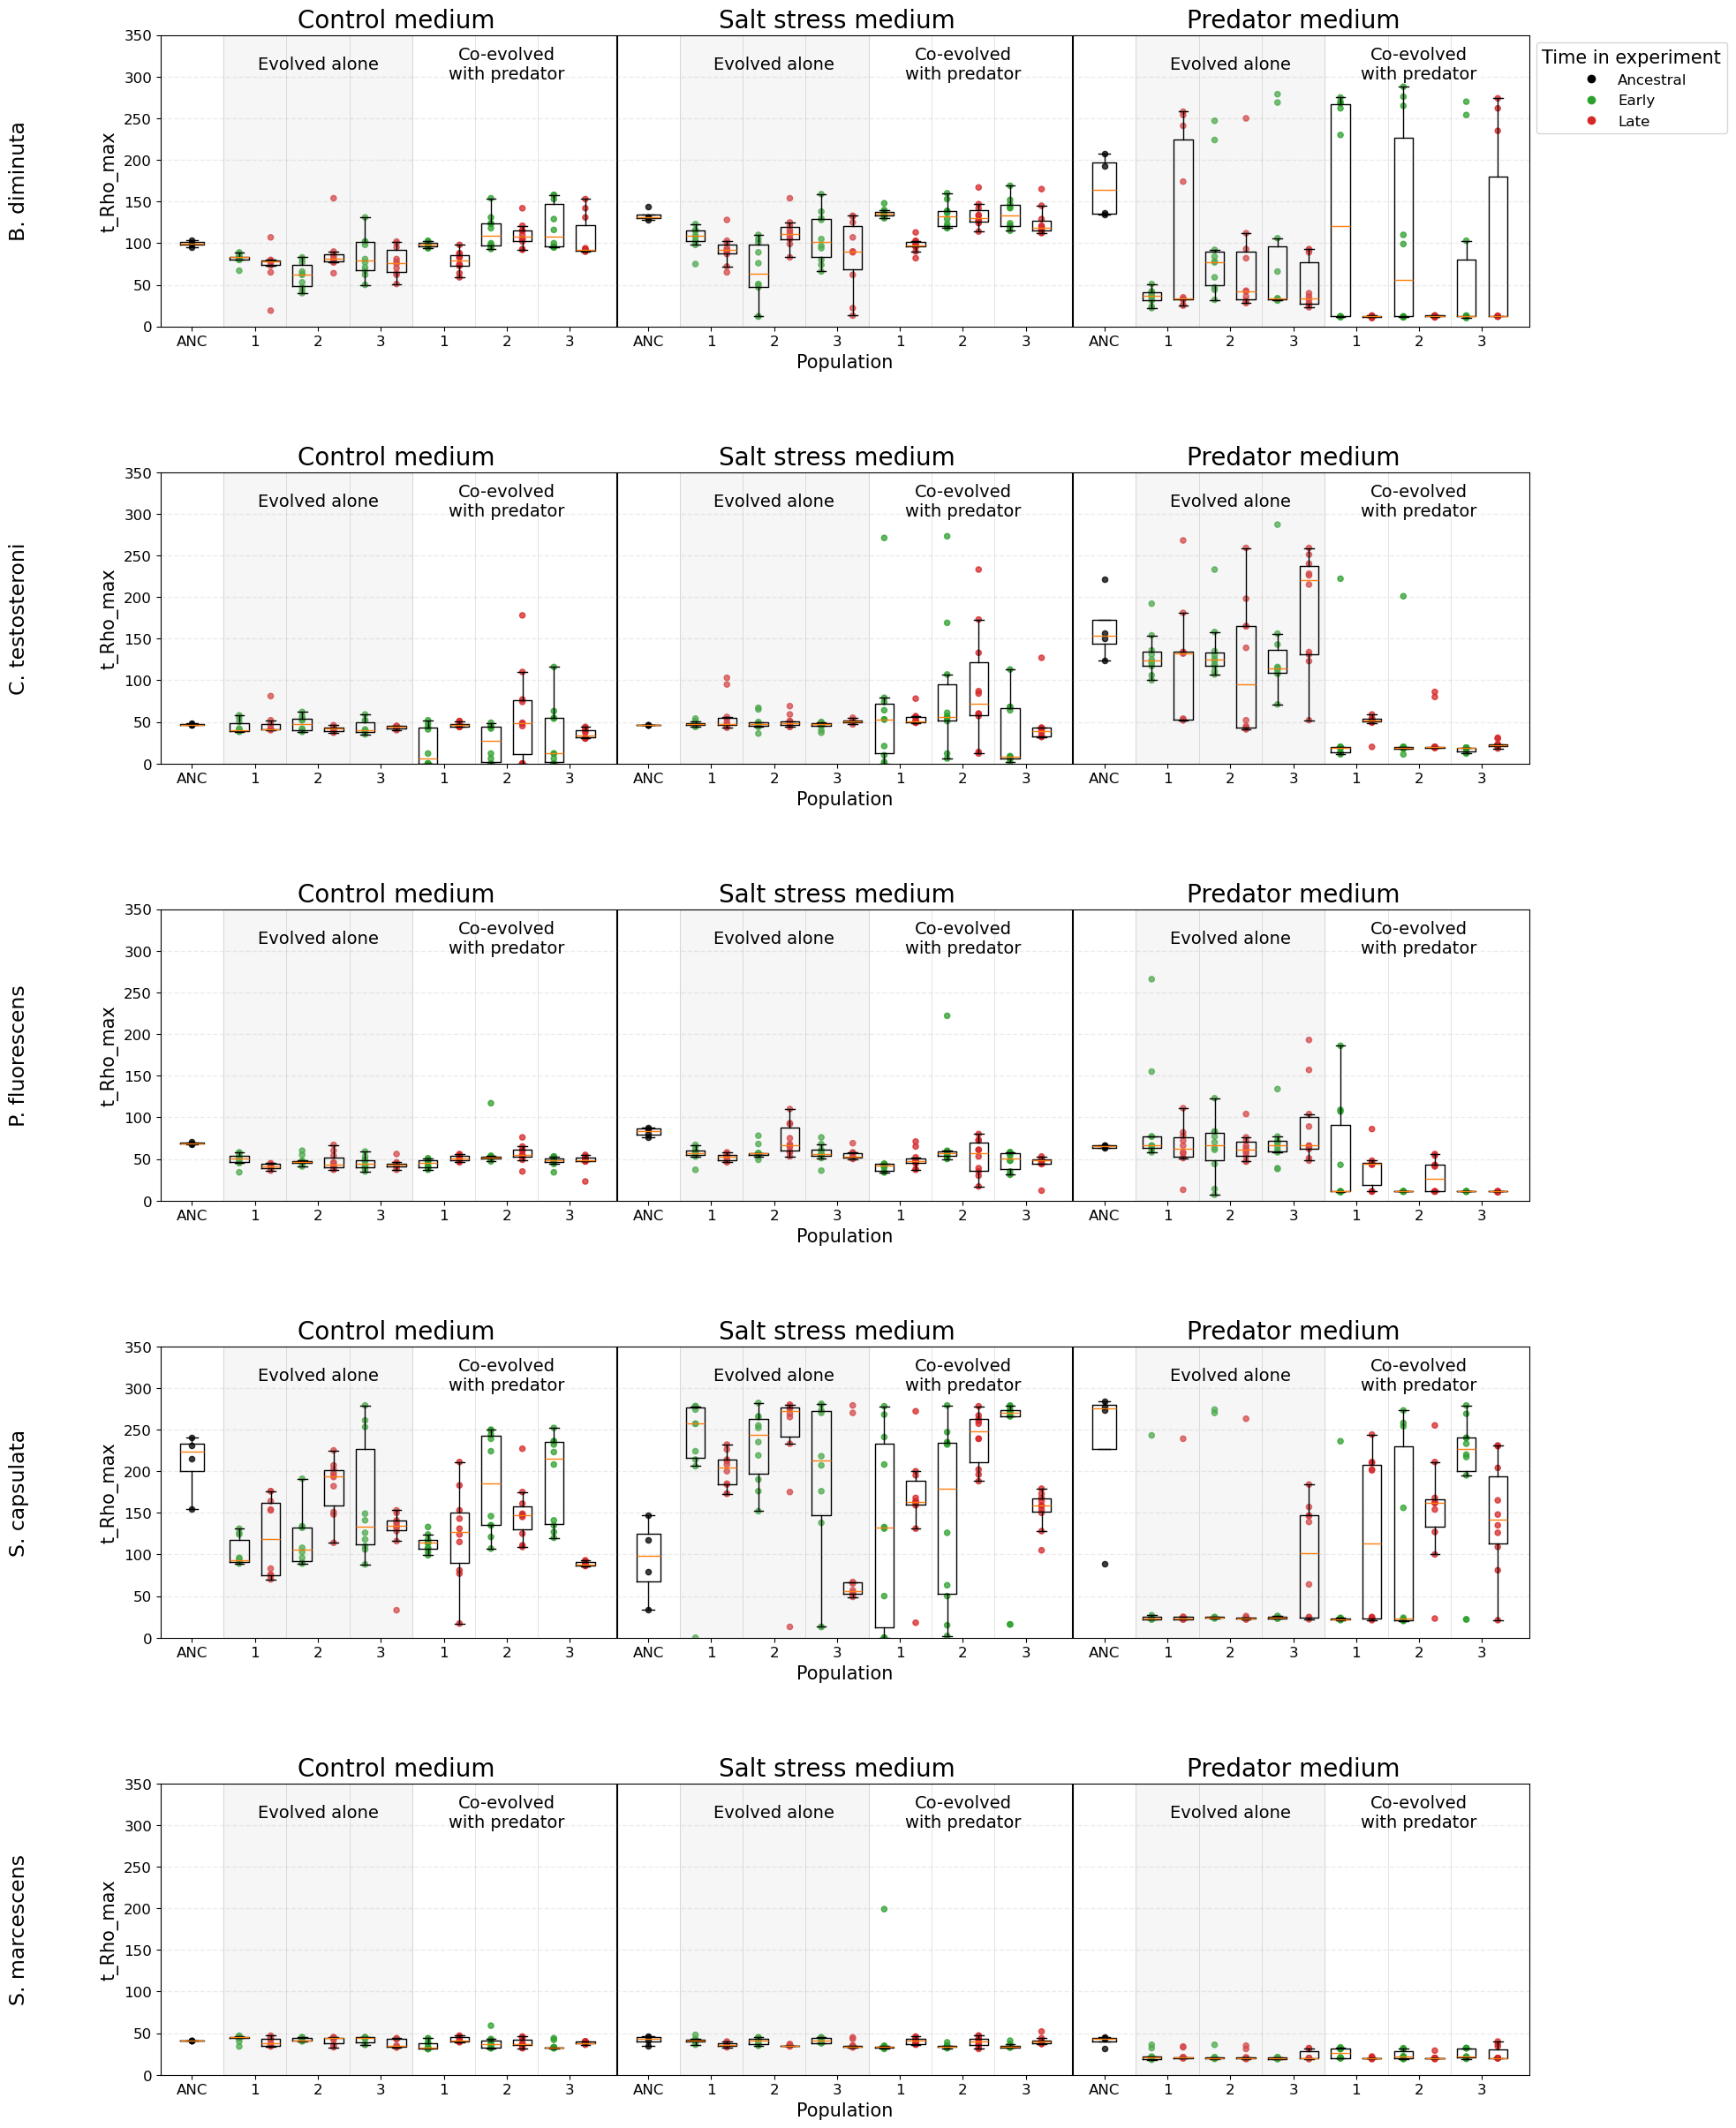

In [12]:
replicates = ["R1", "R2", "R3"]
tps = ["TP1", "TP2"]
colors = ["tab:green", "tab:orange", "tab:red"]
color_dict = {"TP1": "tab:green", "TP2": "tab:red"}
medium_dict = {"KB": kb_m_gr, "Tetra": tetra_m_gr, "KCl": kcl_m_gr}
anc_medium_dict = {"KB": kb_anc_gr, "Tetra": tetra_anc_gr, "KCl": kcl_anc_gr}
species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}
ymax_dict = {"BD": 350, "CT": 350, "PF": 350, "SC": 350, "SM": 350}

custom_lines = [Line2D([0], [0], lw=0, marker="o", color="black", label="Ancestral"),
                Line2D([0], [0], lw=0, marker="o", color="tab:green", label="Early"),
                Line2D([0], [0], lw=0, marker="o", color="tab:red", label="Late")]

box_stats_df = pd.DataFrame(columns=["Mean", "Median", "Variance"])
plt.subplots(5, 1, figsize=(20, 30))
si = 1
for species in ["BD", "CT", "PF", "SC", "SM"]:
    pos = 1.5
    plt.subplot(5, 1, si)
    for medium in ["KB", "KCl", "Tetra"]:
        medium_m = medium_dict[medium]
        anc_medium_m = anc_medium_dict[medium]
        labels = label_dict[medium]
        anc_labels = anc_label_dict[medium]

        ## Ancestral box
        select_anc_labels = np.unique(np.array([x for x in anc_labels if x.split("_")[0] == species]))
        idx = np.array([np.where(anc_labels == x)[0] for x in select_anc_labels]).flatten()
        
        anc_yields = anc_medium_m[idx, -1]
        anc_auc = np.sum(anc_medium_m[idx], axis=1)
        anc_rho_max = np.max(anc_medium_m[idx], axis=1)
        anc_t_rho_max = np.array([np.where(anc_medium_m[idx][i] == anc_rho_max[i])[0][0] for i in range(len(anc_rho_max))])
        anc_y = anc_t_rho_max
        
        plt.boxplot(anc_y, positions=[pos], widths=[0.75], showfliers=False)
        plt.scatter([pos]*len(anc_y), anc_y, c="black", alpha=0.75, s=20)
        pos += 1.5
        
        for hist in ["Evo", "CoEvo"]:
            for replicate in replicates:
                for tp in tps:
                    select_labels = np.unique(np.array([x for x in labels if (x.split("_")[0] == species and x.split("_")[1] == hist and x.split("_")[3] == replicate and x.split("_")[-1] == tp)]))
                    idx = np.array([np.where(labels == x)[0] for x in select_labels]).flatten()
                    scatter_colors = [color_dict[x.split("_")[-1]] for x in labels[idx]]
                    aucs = np.sum(medium_m[idx], axis=1)
                    yields = medium_m[idx, -1]
                    rho_max = np.max(medium_m[idx], axis=1)
                    t_rho_max = np.array([np.where(medium_m[idx][i] == rho_max[i])[0][0] for i in range(len(rho_max))])
                    y = t_rho_max
                    
                    plt.boxplot(y, positions=[pos], widths=[0.6], showfliers=False)
                    plt.scatter([pos]*len(y), y, c=scatter_colors, alpha=0.75, s=20)

                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Mean"] = np.mean(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Median"] = np.median(y)
                    box_stats_df.loc[species + "_" + medium + "_" + hist + "_" + replicate + "_" + tp, "Variance"] = np.var(y)
                    
                    pos += 1
        pos += 1
    
    ymax = ymax_dict[species]
    plt.ylim(0, ymax)
    plt.ylabel("t_Rho_max", fontsize=15)
    plt.yticks(fontsize=12)
    plt.xlabel("Population", fontsize=15)
    
    xtick_labels = ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2 + ["ANC"] + ["1", "2", "3"]*2

    plt.xticks(list(np.arange(1.5, 14, 2)) + list(np.arange(16, 28.5, 2)) + list(np.arange(30.5, 43, 2)), xtick_labels, fontsize=12)
    plt.xlim(0.5, 44)

    plt.vlines([2.5, 4.5, 6.5, 8.5, 10.5, 12.5, 17, 19, 21, 23, 25, 27, 31.5, 33.5, 35.5, 37.5, 39.5, 41.5], 0, ymax, color="black", alpha=0.15, lw=0.5)
    plt.vlines([15, 29.5], 0, ymax, color="black")
    
    plt.axvspan(2.5, 8.5, alpha=0.2, color="lightgray")
    plt.axvspan(17, 23, alpha=0.2, color="lightgray")
    plt.axvspan(31.5, 37.5, alpha=0.2, color="lightgray")

    plt.hlines(plt.gca().get_yticks()[1:-1], 0.5, 44, alpha=0.15, color="gray", linestyle="dashed", lw=1)

    plt.text(5.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(11.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(20, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(26, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(34.5, ymax-ymax*0.1, "Evolved alone", va="center", ha="center", fontsize=14)
    plt.text(40.5, ymax-ymax*0.1, "Co-evolved\nwith predator", va="center", ha="center", fontsize=14)
    
    plt.text(8, ymax+ymax*0.05, "Control medium", va="center", ha="center", fontsize=20)
    plt.text(22, ymax+ymax*0.05, "Salt stress medium", va="center", ha="center", fontsize=20)
    plt.text(36.5, ymax+ymax*0.05, "Predator medium", va="center", ha="center", fontsize=20)
    
    plt.text(-4, ymax/2, species_name_dict[species], va="center", ha="center", fontsize=17, rotation=90)
    

    if si == 1:
        plt.legend(handles=custom_lines, title="Time in experiment", fontsize=12, title_fontsize=15, bbox_to_anchor=(1.15, 1), loc="upper right")

    si += 1 

# plt.savefig("./t_rho_max_boxplot.svg", dpi=200, bbox_inches="tight")
plt.subplots_adjust(hspace=0.5)
plt.show()

In [9]:
# Ancestors
kb_bd_anc_curves = kb_anc_curves[:4]
kb_ct_anc_curves = kb_anc_curves[4:8]
kb_pf_anc_curves = kb_anc_curves[8:12]
kb_sc_anc_curves = kb_anc_curves[12:16]
kb_sm_anc_curves = kb_anc_curves[16:20]

kb_mean_bd_auc = np.mean(np.sum(kb_bd_anc_curves, axis=1))
kb_mean_ct_auc = np.mean(np.sum(kb_ct_anc_curves, axis=1))
kb_mean_pf_auc = np.mean(np.sum(kb_pf_anc_curves, axis=1))
kb_mean_sc_auc = np.mean(np.sum(kb_sc_anc_curves, axis=1))
kb_mean_sm_auc = np.mean(np.sum(kb_sm_anc_curves, axis=1))

kcl_bd_anc_curves = kcl_anc_curves[:4]
kcl_ct_anc_curves = kcl_anc_curves[4:8]
kcl_pf_anc_curves = kcl_anc_curves[8:12]
kcl_sc_anc_curves = kcl_anc_curves[12:16]
kcl_sm_anc_curves = kcl_anc_curves[16:20]

kcl_mean_bd_auc = np.mean(np.sum(kcl_bd_anc_curves, axis=1))
kcl_mean_ct_auc = np.mean(np.sum(kcl_ct_anc_curves, axis=1))
kcl_mean_pf_auc = np.mean(np.sum(kcl_pf_anc_curves, axis=1))
kcl_mean_sc_auc = np.mean(np.sum(kcl_sc_anc_curves, axis=1))
kcl_mean_sm_auc = np.mean(np.sum(kcl_sm_anc_curves, axis=1))

tetra_bd_anc_curves = tetra_anc_curves[:4]
tetra_ct_anc_curves = tetra_anc_curves[4:8]
tetra_pf_anc_curves = tetra_anc_curves[8:12]
tetra_sc_anc_curves = tetra_anc_curves[12:16]
tetra_sm_anc_curves = tetra_anc_curves[16:20]

tetra_mean_bd_auc = np.mean(np.sum(tetra_bd_anc_curves, axis=1))
tetra_mean_ct_auc = np.mean(np.sum(tetra_ct_anc_curves, axis=1))
tetra_mean_pf_auc = np.mean(np.sum(tetra_pf_anc_curves, axis=1))
tetra_mean_sc_auc = np.mean(np.sum(tetra_sc_anc_curves, axis=1))
tetra_mean_sm_auc = np.mean(np.sum(tetra_sm_anc_curves, axis=1))

# Evolved/coevolved
medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
anc_medium_dict = {"KB": kb_anc_curves, "Tetra": tetra_anc_curves, "KCl": kcl_anc_curves}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}
anc_label_dict = {"KB": kb_anc_labels, "Tetra": tetra_anc_labels, "KCl": kcl_anc_labels}
anc_mean_auc_means_dict = {"KB_BD": kb_mean_bd_auc, "KB_CT": kb_mean_ct_auc, "KB_PF": kb_mean_pf_auc, "KB_SC": kb_mean_sc_auc, "KB_SM": kb_mean_sm_auc,
                           "KCl_BD": kcl_mean_bd_auc, "KCl_CT": kcl_mean_ct_auc, "KCl_PF": kcl_mean_pf_auc, "KCl_SC": kcl_mean_sc_auc, "KCl_SM": kcl_mean_sm_auc,
                           "Tetra_BD": tetra_mean_bd_auc, "Tetra_CT": tetra_mean_ct_auc, "Tetra_PF": tetra_mean_pf_auc, "Tetra_SC": tetra_mean_sc_auc, "Tetra_SM": tetra_mean_sm_auc}

all_auc_ratios = []
all_auc_labels = []

for species in ["BD", "CT", "PF", "SC", "SM"]:
    for medium in ["KB", "KCl", "Tetra"]:
        for hist in ["Evo", "CoEvo"]:
            medium_curves = medium_dict[medium]
            medium_labels = label_dict[medium]
            anc_medium_curves = anc_medium_dict[medium]
            anc_medium_labels = anc_label_dict[medium]
            
            for replicate in ["R1", "R2", "R3"]:
                for time_point in ["TP1", "TP2"]:
                    
                    idx = [i for i in range(len(medium_labels)) if medium_labels[i].split("_")[0] == species and medium_labels[i].split("_")[1] == hist and medium_labels[i].split("_")[3] == replicate and medium_labels[i].split("_")[4] == time_point]
                    aucs = np.sum(medium_curves[idx], axis=1)
                    auc_ratios = aucs/anc_mean_auc_means_dict[medium + "_" + species]

                    all_auc_ratios.append(auc_ratios)
                    all_auc_labels.append("_".join([species, hist, medium, replicate, time_point]))

## Relative fitness and linear mixed model results

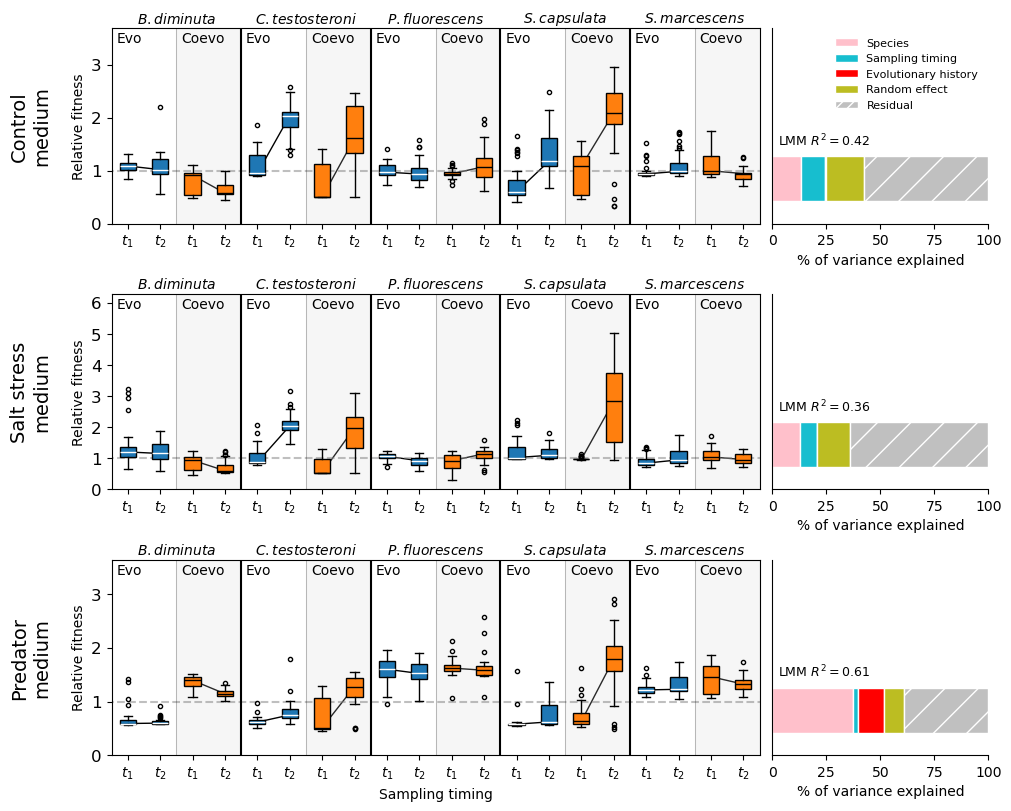

In [10]:
from scipy.stats import gaussian_kde
from matplotlib.ticker import MaxNLocator
import matplotlib.patches as mpatches

# Results from R's lmer
r2_no_interaction_decomp = pd.read_csv("no_interaction_R2_decomposition.csv", index_col=0)
r2_no_interaction_decomp = r2_no_interaction_decomp.replace("Treatment", "Evolutionary history")
r2_no_interaction_decomp = r2_no_interaction_decomp.replace("Timepoint", "Sampling timing")
r2_no_interaction_decomp = r2_no_interaction_decomp.replace("Random", "Random effect")
total_r2 = {"Control": 0.4238177, "Salt stress": 0.3580509, "Predator": 0.6093275}

term_colors = {"Species": "pink", "Sampling timing": "tab:cyan", "Evolutionary history": "red", "Random effect": "tab:olive", "Residual": "silver"}

custom_legend = [mpatches.Patch(facecolor=term_colors["Species"], label='Species', edgecolor="white"),
                 mpatches.Patch(facecolor=term_colors["Sampling timing"], label='Sampling timing', edgecolor="white"),
                 mpatches.Patch(facecolor=term_colors["Evolutionary history"], label='Evolutionary history', edgecolor="white"),
                 mpatches.Patch(facecolor=term_colors["Random effect"], label='Random effect', edgecolor="white"),
                 mpatches.Patch(facecolor=term_colors["Residual"],hatch="///", label='Residual', edgecolor="white")]


species_name_dict = {"BD": "B. diminuta", "CT": "C. testosteroni", "PF": "P. fluorescens", "SC": "S. capsulata", "SM": "S. marcescens"}
tab_green_rgba = list(matplotlib.colors.to_rgba("tab:green"))
tab_green_rgba[-1] = 0.5
tab_red_rgba = list(matplotlib.colors.to_rgba("tab:red"))
tab_red_rgba[-1] = 0.5

box_colors = ["tab:blue"]*6 + ["tab:orange"]*6 + ["tab:blue"]*6 + ["tab:orange"]*6 + ["tab:blue"]*6 + ["tab:orange"]*6
scatter_colors = ["tab:green", "tab:red"]*18
box_width = 0.5
medium_fontsize = 10
history_fontsize = 12
species_fontsize = 14
xlabel_fontsize = 10
ylabel_fontsize = 10
xtick_fontsize = 11
si = 1

hist_facecolor_dict = {"Evo": "tab:blue", "CoEvo": "tab:orange"}

all_auc_labels_wo_rep = ["_".join([x.split("_")[0], x.split("_")[1], x.split("_")[2], x.split("_")[4]]) for x in all_auc_labels]

mediums = ["KB", "KCl", "Tetra"]
medium_names = {"KB": "Control", "KCl": "Salt stress", "Tetra": "Predator"}

fig = plt.figure(layout="constrained", figsize=(10, 8))
gridspec = fig.add_gridspec(ncols=4, nrows=len(mediums))


for med_i in range(len(mediums)):
    medium = mediums[med_i]
    ax0 = fig.add_subplot(gridspec[med_i, 0:3])
    plt.hlines(1, -1, 20, linestyle="dashed", color="gray", alpha=0.5)
    pos = 0
    for species in ["BD", "CT", "PF", "SC", "SM"]:
        for hist in ["Evo", "CoEvo"]:
            for tp in ["TP1", "TP2"]:
                idx = [i for i in range(len(all_auc_labels)) if all_auc_labels[i].split("_")[0] == species and all_auc_labels[i].split("_")[1] == hist and all_auc_labels[i].split("_")[2] == medium and all_auc_labels[i].split("_")[4] == tp]
                selected_labels = np.array(all_auc_labels)[idx]
                selected_ratios = np.array(all_auc_ratios)[idx].flatten()
        
                x = selected_ratios
                bp = plt.boxplot(x, positions=[pos], widths=[box_width], patch_artist=True, zorder=10, flierprops={"markersize": 3}, showfliers=True)
                if hist == "Evo":
                    bp['boxes'][0].set_facecolor("tab:blue")
                    bp['medians'][0].set_color('white')
                else:
                    bp['boxes'][0].set_facecolor("tab:orange")
                    bp['medians'][0].set_color('black')
            
                kde = gaussian_kde(x)
                density = kde(x)
                jitter = 0
                xvals = pos + (density * jitter * 0.01 * 2)
                pos += 1
            
            tp1_idx = [i for i in range(len(all_auc_labels)) if all_auc_labels[i].split("_")[0] == species and all_auc_labels[i].split("_")[1] == hist and all_auc_labels[i].split("_")[2] == medium and all_auc_labels[i].split("_")[4] == "TP1"]
            selected_tp1_labels = np.array(all_auc_labels)[tp1_idx]
            selected_tp1_ratios = np.array(all_auc_ratios)[tp1_idx].flatten()

            tp2_idx = [i for i in range(len(all_auc_labels)) if all_auc_labels[i].split("_")[0] == species and all_auc_labels[i].split("_")[1] == hist and all_auc_labels[i].split("_")[2] == medium and all_auc_labels[i].split("_")[4] == "TP2"]
            selected_tp2_labels = np.array(all_auc_labels)[tp2_idx]
            selected_tp2_ratios = np.array(all_auc_ratios)[tp2_idx].flatten()
            
            x1 = selected_tp1_ratios
            x2 = selected_tp2_ratios
            plt.plot([pos-2, pos-1], [np.median(x1), np.median(x2)], zorder=0, color="black", lw=1)


    idx = [i for i in range(len(all_auc_labels)) if all_auc_labels[i].split("_")[2] == medium]
    selected_labels = np.array(all_auc_labels)[idx]
    selected_ratios = np.array(all_auc_ratios)[idx].flatten()
    ymax = np.max(selected_ratios)
    ymax = ymax + ymax*0.25
    
    plt.xlim(-0.5, 20-0.5)
    plt.ylim(0, ymax)
    plt.yticks(fontsize=12)
    plt.ylabel("Relative fitness", fontsize=ylabel_fontsize)

    pop_labels = ['Evo', 'Coevo']*5
    i = 0
    for x in pop_labels:
        plt.text(i-0.35, ymax-ymax*0.075, x)
        i += 2

    xtick_labels = ['$t_1$', '$t_2$']*10
    plt.xticks(list(np.arange(0, 20, 1)), xtick_labels)


    plt.axvspan(1.5, 3.5, alpha=0.2, color="lightgray")
    plt.axvspan(5.5, 7.5, alpha=0.2, color="lightgray")
    plt.axvspan(9.5, 11.5, alpha=0.2, color="lightgray")
    plt.axvspan(13.5, 15.5, alpha=0.2, color="lightgray")
    plt.axvspan(17.5, 19.5, alpha=0.2, color="lightgray")

    plt.vlines([1.5, 5.5, 9.5, 13.5, 17.5], 0, ymax, color="black", alpha=0.35, lw=0.5)
    plt.vlines([3.5, 7.5, 11.5, 15.5], 0, ymax, color="black")

    plt.text(0.1, 1.05, "$B. diminuta$", va="center", ha="center", fontsize=medium_fontsize, transform=plt.gca().transAxes)
    plt.text(0.3, 1.05, "$C. testosteroni$", va="center", ha="center", fontsize=medium_fontsize, transform=plt.gca().transAxes)
    plt.text(0.5, 1.05, "$P. fluorescens$", va="center", ha="center", fontsize=medium_fontsize, transform=plt.gca().transAxes)
    plt.text(0.7, 1.05, "$S. capsulata$", va="center", ha="center", fontsize=medium_fontsize, transform=plt.gca().transAxes)
    plt.text(0.9, 1.05, "$S. marcescens$", va="center", ha="center", fontsize=medium_fontsize, transform=plt.gca().transAxes)
    
    if si == 5:
        plt.xlabel("Sampling time point", fontsize=xlabel_fontsize)

    if si == 1:
        plt.text(-3, ymax/2, 'Control\nmedium', va="center", ha="center", fontsize=species_fontsize, rotation=90)
    elif si == 2:
        plt.text(-3, ymax/2, 'Salt stress\nmedium', va="center", ha="center", fontsize=species_fontsize, rotation=90)
    else:
        plt.text(-3, ymax/2, 'Predator\nmedium', va="center", ha="center", fontsize=species_fontsize, rotation=90)
        plt.xlabel("Sampling timing")
    ax = plt.gca()
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    

    ax1 = fig.add_subplot(gridspec[med_i, 3])
    left = 0
    for term in ["Species", "Sampling timing", "Evolutionary history", "Random effect", "Residual"]:
        y = r2_no_interaction_decomp[(r2_no_interaction_decomp["Medium"] == medium_names[medium]) & (r2_no_interaction_decomp["Term"] == term)]["R2"].values[0]
        if term == "Residual":
            hatch = "/"
        else:
            hatch = None
        plt.barh(0, y, 0.15, label=term, left=left, color=term_colors[term], hatch=hatch, edgecolor="white")
        left += y
    plt.ylim(-0.15, 0.5)
    plt.xticks([0, 0.25, 0.5, 0.75, 1], [0, 25, 50, 75, 100])
    plt.yticks([], [])
    plt.xlim(0, 1)
    plt.text(0.025, 0.4, "LMM $R^2 = $" + str(np.round(total_r2[medium_names[medium]], 2)), transform=plt.gca().transAxes, fontsize=9)
    
    if si == 1:
        plt.legend(handles=custom_legend, bbox_to_anchor=(1, 1), fontsize=8, frameon=False)
    
    # if si == 3:
    plt.xlabel("% of variance explained")

    ax1.spines[["right", "top"]].set_visible(False)
    si += 1

# plt.tight_layout()
# plt.savefig("auc_ratios.pdf", dpi=300)
plt.show()

# Mean difference between time points

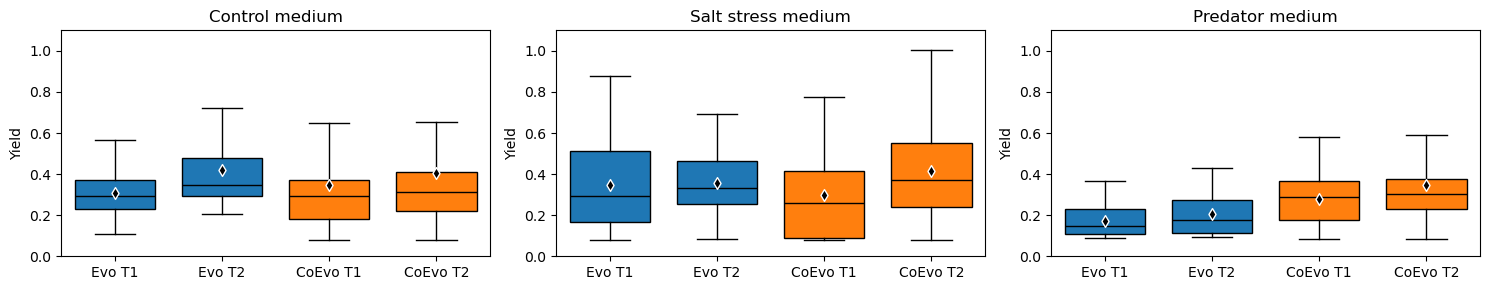

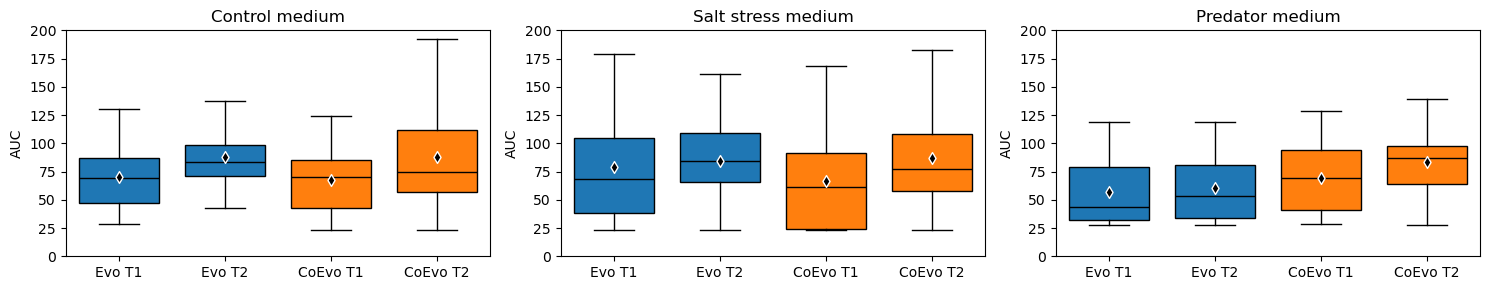

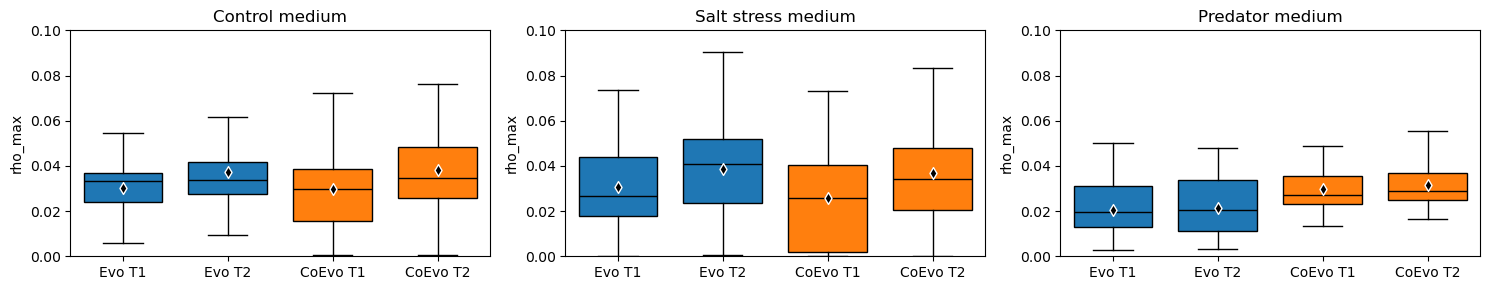

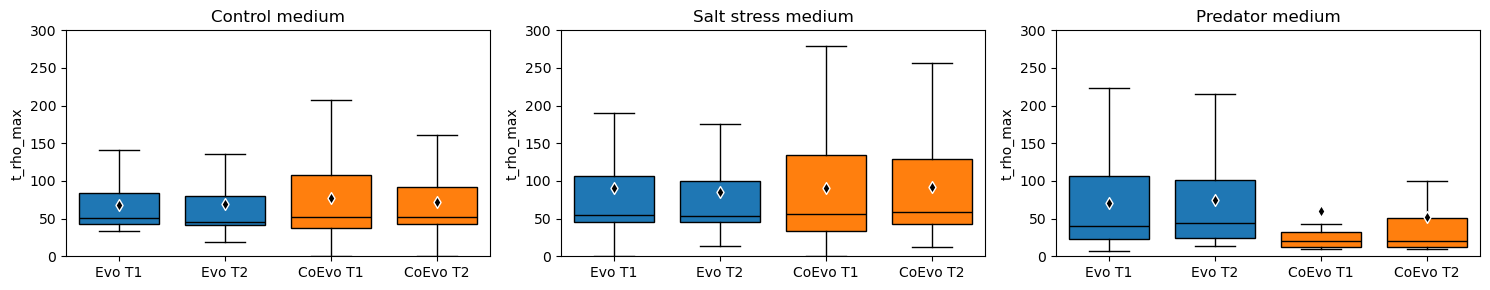

In [15]:
from scipy.stats import gaussian_kde

medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
medium_gr_dict = {"KB": kb_m_gr, "Tetra": tetra_m_gr, "KCl": kcl_m_gr}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}

hist_colors = {"Evo": "tab:blue", "CoEvo": "tab:orange"}
metrics = ["Yield", "AUC", "rho_max", "t_rho_max"]
medium_title_dict = {"KB": "Control medium", "KCl": "Salt stress medium", "Tetra": "Predator medium"}


for metric in metrics:
    plt.subplots(1, 3, figsize=(15, 3))
    si = 1
    for medium in ["KB", "KCl", "Tetra"]:
    
        medium_m = medium_dict[medium]
        medium_gr_m = medium_gr_dict[medium]
        labels = label_dict[medium]
    
        # idx = [i for i in range(len(labels)) if labels[i].split("_")[-1] != "TP3"]  # Remove third time point
        t1_idx = [i for i in range(len(labels)) if labels[i].split("_")[-1] == "TP1"]
        t2_idx = [i for i in range(len(labels)) if labels[i].split("_")[-1] == "TP2"]
        
        t1_medium_m = medium_m[t1_idx]
        t1_medium_gr_m = medium_gr_m[t1_idx]
        t1_labels = labels[t1_idx]

        t2_medium_m = medium_m[t2_idx]
        t2_medium_gr_m = medium_gr_m[t2_idx]
        t2_labels = labels[t2_idx]
    
        
        plt.subplot(1, 3, si)
        box_pos = 0
        for hist in ["Evo", "CoEvo"]:
            t1_select_labels = np.unique(np.array([x for x in t1_labels if (x.split("_")[1] == hist)]))
            t1_idx = np.array([np.where(t1_labels == x)[0] for x in t1_select_labels]).flatten()
            t1_rho_max = np.max(t1_medium_gr_m[t1_idx], axis=1)
            t1_t_rho_max = [np.where(t1_medium_gr_m[t1_idx][i] == t1_rho_max[i])[0][0] for i in range(len(t1_rho_max))]
            t1_yields = t1_medium_m[t1_idx, -1]
            t1_auc = np.sum(t1_medium_m[t1_idx], axis=1)

            t2_select_labels = np.unique(np.array([x for x in t2_labels if (x.split("_")[1] == hist)]))
            t2_idx = np.array([np.where(t2_labels == x)[0] for x in t2_select_labels]).flatten()
            t2_rho_max = np.max(t2_medium_gr_m[t2_idx], axis=1)
            t2_t_rho_max = [np.where(t2_medium_gr_m[t2_idx][i] == t2_rho_max[i])[0][0] for i in range(len(t2_rho_max))]
            t2_yields = t2_medium_m[t2_idx, -1]
            t2_auc = np.sum(t2_medium_m[t2_idx], axis=1)
    
            if metric == "Yield":
                t1_y = t1_yields
                t2_y = t2_yields
                ylim = (0, 1.1)
            elif metric == "AUC":
                t1_y = t1_auc
                t2_y = t2_auc
                ylim = (0, 200)
            elif metric == "rho_max":
                t1_y = t1_rho_max
                t2_y = t2_rho_max
                ylim = (0, 0.1)
            elif metric == "t_rho_max":
                t1_y = t1_t_rho_max
                t2_y = t2_t_rho_max
                ylim = (0, 300)

            t1_bplot = plt.boxplot(t1_y, positions=[box_pos], widths=[0.75], notch=False, vert=True, showfliers=False, patch_artist=True)
            t1_bplot["boxes"][0].set_facecolor(hist_colors[hist])
            t1_bplot["medians"][0].set_color("black")
            t1_mean = np.mean(t1_y)
            plt.scatter(box_pos, t1_mean, color="black", marker="d", edgecolor="white", zorder=10)

            t2_bplot = plt.boxplot(t2_y, positions=[box_pos+1], widths=[0.75], notch=False, vert=True, showfliers=False, patch_artist=True)
            t2_bplot["boxes"][0].set_facecolor(hist_colors[hist])
            t2_bplot["medians"][0].set_color("black")
            t2_mean = np.mean(t2_y)
            plt.scatter(box_pos+1, t2_mean, color="black", marker="d", edgecolor="white", zorder=10)
    
            box_pos += 2

        plt.ylim(ylim)
        plt.title(medium_title_dict[medium])
        # plt.yticks([1, 0], ["Evo", "CoEvo"])
        plt.xticks([0, 1, 2, 3], ["Evo T1", "Evo T2", "CoEvo T1", "CoEvo T2"])
        plt.ylabel(metric)
        si += 1
        
    plt.tight_layout()
    plt.show()

In [16]:
medium_dict = {"KB": kb_m, "Tetra": tetra_m, "KCl": kcl_m}
medium_gr_dict = {"KB": kb_m_gr, "Tetra": tetra_m_gr, "KCl": kcl_m_gr}
label_dict = {"KB": kb_labels, "Tetra": tetra_labels, "KCl": kcl_labels}

hist_colors = {"Evo": "tab:blue", "CoEvo": "tab:orange"}
metrics = ["Yield", "AUC", "rho_max", "t_rho_max"]
medium_title_dict = {"KB": "Control medium", "KCl": "Salt stress medium", "Tetra": "Predator medium"}

data_bar = {}
for medium in ["KB", "KCl", "Tetra"]:

    medium_m = medium_dict[medium]
    medium_gr_m = medium_gr_dict[medium]
    labels = label_dict[medium]

    t1_idx = [i for i in range(len(labels)) if labels[i].split("_")[-1] == "TP1"]
    t2_idx = [i for i in range(len(labels)) if labels[i].split("_")[-1] == "TP2"]
    
    t1_medium_m = medium_m[t1_idx]
    t1_medium_gr_m = medium_gr_m[t1_idx]
    t1_labels = labels[t1_idx]

    t2_medium_m = medium_m[t2_idx]
    t2_medium_gr_m = medium_gr_m[t2_idx]
    t2_labels = labels[t2_idx]

    # Evo
    t1_select_labels = np.unique(np.array([x for x in t1_labels if (x.split("_")[1] == "Evo")]))
    t1_idx = np.array([np.where(t1_labels == x)[0] for x in t1_select_labels]).flatten()
    t1_rho_max = np.max(t1_medium_gr_m[t1_idx], axis=1)
    t1_t_rho_max = np.array([np.where(t1_medium_gr_m[t1_idx][i] == t1_rho_max[i])[0][0] for i in range(len(t1_rho_max))])
    t1_yields = t1_medium_m[t1_idx, -1]
    t1_auc = np.sum(t1_medium_m[t1_idx], axis=1)

    t2_select_labels = np.unique(np.array([x for x in t2_labels if (x.split("_")[1] == "Evo")]))
    t2_idx = np.array([np.where(t2_labels == x)[0] for x in t2_select_labels]).flatten()
    t2_rho_max = np.max(t2_medium_gr_m[t2_idx], axis=1)
    t2_t_rho_max = np.array([np.where(t2_medium_gr_m[t2_idx][i] == t2_rho_max[i])[0][0] for i in range(len(t2_rho_max))])
    t2_yields = t2_medium_m[t2_idx, -1]
    t2_auc = np.sum(t2_medium_m[t2_idx], axis=1)

    evo_medium_yield_diff_mean = np.mean(t2_yields) - np.mean(t1_yields)
    evo_medium_auc_diff_mean = np.mean(t2_auc) - np.mean(t1_auc)
    evo_medium_rho_max_diff_mean = np.mean(t2_rho_max) - np.mean(t1_rho_max)
    evo_medium_t_rho_max_diff_mean = np.mean(t2_t_rho_max) - np.mean(t1_t_rho_max)

    # CoEvo
    t1_select_labels = np.unique(np.array([x for x in t1_labels if (x.split("_")[1] == "CoEvo")]))
    t1_idx = np.array([np.where(t1_labels == x)[0] for x in t1_select_labels]).flatten()
    t1_rho_max = np.max(t1_medium_gr_m[t1_idx], axis=1)
    t1_t_rho_max = np.array([np.where(t1_medium_gr_m[t1_idx][i] == t1_rho_max[i])[0][0] for i in range(len(t1_rho_max))])
    t1_yields = t1_medium_m[t1_idx, -1]
    t1_auc = np.sum(t1_medium_m[t1_idx], axis=1)

    t2_select_labels = np.unique(np.array([x for x in t2_labels if (x.split("_")[1] == "CoEvo")]))
    t2_idx = np.array([np.where(t2_labels == x)[0] for x in t2_select_labels]).flatten()
    t2_rho_max = np.max(t2_medium_gr_m[t2_idx], axis=1)
    t2_t_rho_max = np.array([np.where(t2_medium_gr_m[t2_idx][i] == t2_rho_max[i])[0][0] for i in range(len(t2_rho_max))])
    t2_yields = t2_medium_m[t2_idx, -1]
    t2_auc = np.sum(t2_medium_m[t2_idx], axis=1)

    coevo_medium_yield_diff_mean = np.mean(t2_yields) - np.mean(t1_yields)
    coevo_medium_auc_diff_mean = np.mean(t2_auc) - np.mean(t1_auc)
    coevo_medium_rho_max_diff_mean = np.mean(t2_rho_max) - np.mean(t1_rho_max)
    coevo_medium_t_rho_max_diff_mean = np.mean(t2_t_rho_max) - np.mean(t1_t_rho_max)

    data_bar["Evo_" + medium + "_yield"] = evo_medium_yield_diff_mean
    data_bar["Evo_" + medium + "_auc"] = evo_medium_auc_diff_mean
    data_bar["Evo_" + medium + "_rho_max"] = evo_medium_rho_max_diff_mean
    data_bar["Evo_" + medium + "_t_rho_max"] = evo_medium_t_rho_max_diff_mean
     
    data_bar["CoEvo_" + medium + "_yield"] = coevo_medium_yield_diff_mean
    data_bar["CoEvo_" + medium + "_auc"] = coevo_medium_auc_diff_mean
    data_bar["CoEvo_" + medium + "_rho_max"] = coevo_medium_rho_max_diff_mean
    data_bar["CoEvo_" + medium + "_t_rho_max"] = coevo_medium_t_rho_max_diff_mean

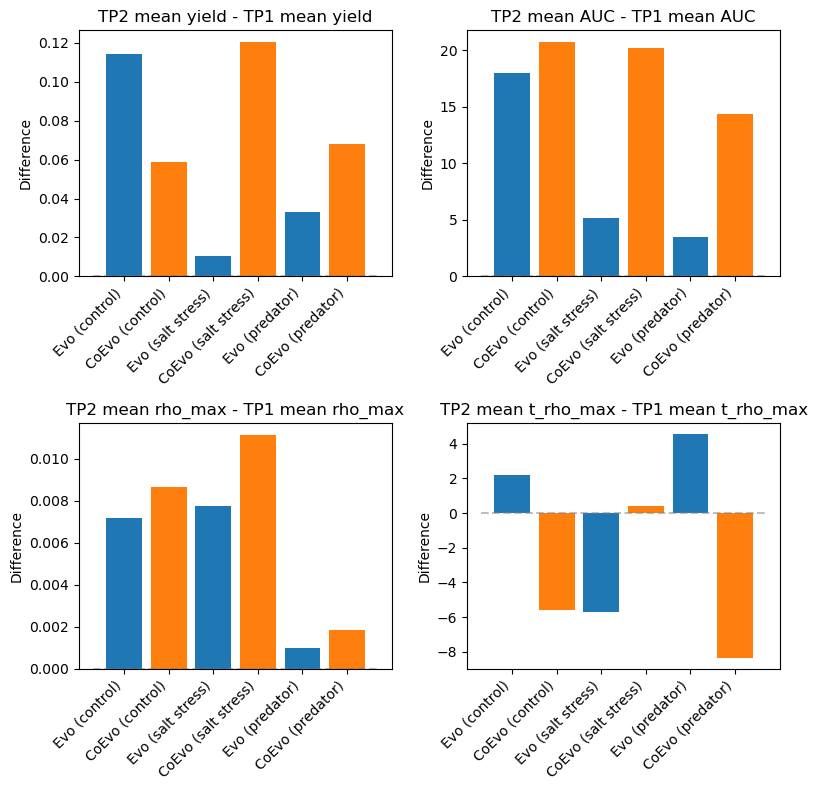

In [17]:
plt.subplots(2, 2, figsize=(8, 8))
plt.subplot(221)
plt.bar(range(6), [data_bar["Evo_KB_yield"], data_bar["CoEvo_KB_yield"], data_bar["Evo_KCl_yield"], data_bar["CoEvo_KCl_yield"], data_bar["Evo_Tetra_yield"], data_bar["CoEvo_Tetra_yield"]], color=["tab:blue", "tab:orange"]*3)
plt.hlines(0, plt.xlim()[0], plt.xlim()[1], color="grey", alpha=0.5, linestyle="dashed")
plt.title("TP2 mean yield - TP1 mean yield")
plt.xticks(range(6), ["Evo (control)", "CoEvo (control)", "Evo (salt stress)", "CoEvo (salt stress)", "Evo (predator)", "CoEvo (predator)"], rotation=45, ha="right")
plt.ylabel("Difference")

plt.subplot(222)
plt.bar(range(6), [data_bar["Evo_KB_auc"], data_bar["CoEvo_KB_auc"], data_bar["Evo_KCl_auc"], data_bar["CoEvo_KCl_auc"], data_bar["Evo_Tetra_auc"], data_bar["CoEvo_Tetra_auc"]], color=["tab:blue", "tab:orange"]*3)
plt.hlines(0, plt.xlim()[0], plt.xlim()[1], color="grey", alpha=0.5, linestyle="dashed")
plt.title("TP2 mean AUC - TP1 mean AUC")
plt.xticks(range(6), ["Evo (control)", "CoEvo (control)", "Evo (salt stress)", "CoEvo (salt stress)", "Evo (predator)", "CoEvo (predator)"], rotation=45, ha="right")
plt.ylabel("Difference")

plt.subplot(223)
plt.bar(range(6), [data_bar["Evo_KB_rho_max"], data_bar["CoEvo_KB_rho_max"], data_bar["Evo_KCl_rho_max"], data_bar["CoEvo_KCl_rho_max"], data_bar["Evo_Tetra_rho_max"], data_bar["CoEvo_Tetra_rho_max"]], color=["tab:blue", "tab:orange"]*3)
plt.hlines(0, plt.xlim()[0], plt.xlim()[1], color="grey", alpha=0.5, linestyle="dashed")
plt.title("TP2 mean rho_max - TP1 mean rho_max")
plt.xticks(range(6), ["Evo (control)", "CoEvo (control)", "Evo (salt stress)", "CoEvo (salt stress)", "Evo (predator)", "CoEvo (predator)"], rotation=45, ha="right")
plt.ylabel("Difference")

plt.subplot(224)
plt.bar(range(6), [data_bar["Evo_KB_t_rho_max"], data_bar["CoEvo_KB_t_rho_max"], data_bar["Evo_KCl_t_rho_max"], data_bar["CoEvo_KCl_t_rho_max"], data_bar["Evo_Tetra_t_rho_max"], data_bar["CoEvo_Tetra_t_rho_max"]], color=["tab:blue", "tab:orange"]*3)
plt.hlines(0, plt.xlim()[0], plt.xlim()[1], color="grey", alpha=0.5, linestyle="dashed")
plt.title("TP2 mean t_rho_max - TP1 mean t_rho_max")
plt.xticks(range(6), ["Evo (control)", "CoEvo (control)", "Evo (salt stress)", "CoEvo (salt stress)", "Evo (predator)", "CoEvo (predator)"], rotation=45, ha="right")
plt.ylabel("Difference")
plt.tight_layout()
# plt.savefig("TP2-TP1_differences.png")
plt.show()

# Random Forest

## Predicting species + history + replicate + time point

In [18]:
idx = [i for i in range(len(combined_all_labels)) if combined_all_labels[i].split("_")[-1] != "TP3"]  # Remove third time point

data = np.vstack([combined_all_m[idx], combined_anc_m])
rf_labels = np.array([x.split("_")[0] + "_" + x.split("_")[1] + "_" + x.split("_")[3] + "_" + x.split("_")[4] for x in combined_all_labels])[idx]
rf_labels = np.array(list(rf_labels) + list(combined_anc_labels))


sorted_indices = [x for _, x in sorted(zip(rf_labels, list(range(len(data)))))]
rf_labels = rf_labels[sorted_indices]
data = data[sorted_indices]

In [19]:
cm = np.zeros((len(np.unique(rf_labels)), len(np.unique(rf_labels))))
fi = np.zeros(data.shape[1])
scores = []
for i in range(100):
    np.random.seed(i)
    x_train, x_test, y_train, y_test = train_test_split(data, rf_labels, test_size=0.5, stratify=rf_labels)
    rf = RandomForestClassifier(n_estimators=200)
    rf.fit(x_train, y_train)
    score = rf.score(x_test, y_test)
    scores.append(score)
    cm += confusion_matrix(y_test, rf.predict(x_test), labels=sorted(np.unique(rf_labels)))
    fi += rf.feature_importances_
    print(i, score)

0 0.6064516129032258
1 0.6096774193548387
2 0.6290322580645161
3 0.5806451612903226
4 0.6258064516129033
5 0.5806451612903226
6 0.5645161290322581
7 0.6258064516129033
8 0.632258064516129
9 0.5806451612903226
10 0.5741935483870968
11 0.5838709677419355
12 0.603225806451613
13 0.6387096774193548
14 0.6225806451612903
15 0.5870967741935483
16 0.5838709677419355
17 0.567741935483871
18 0.6129032258064516
19 0.6096774193548387
20 0.6290322580645161
21 0.603225806451613
22 0.6161290322580645
23 0.5806451612903226
24 0.5903225806451613
25 0.5419354838709678
26 0.5870967741935483
27 0.6064516129032258
28 0.6
29 0.5612903225806452
30 0.6129032258064516
31 0.6096774193548387
32 0.6161290322580645
33 0.5838709677419355
34 0.6129032258064516
35 0.5548387096774193
36 0.6096774193548387
37 0.5838709677419355
38 0.5838709677419355
39 0.6193548387096774
40 0.6290322580645161
41 0.6258064516129033
42 0.5935483870967742
43 0.5935483870967742
44 0.6612903225806451
45 0.5838709677419355
46 0.583870967741

In [20]:
np.mean(scores)

0.6009354838709678

In [21]:
cm_norm = cm.copy()
for i in range(cm_norm.shape[0]):
    if i in [0, 13, 13*2, 13*3, 13*4]:
        cm_norm[i, :] /= 200
    else:
        cm_norm[i, :] /= 500

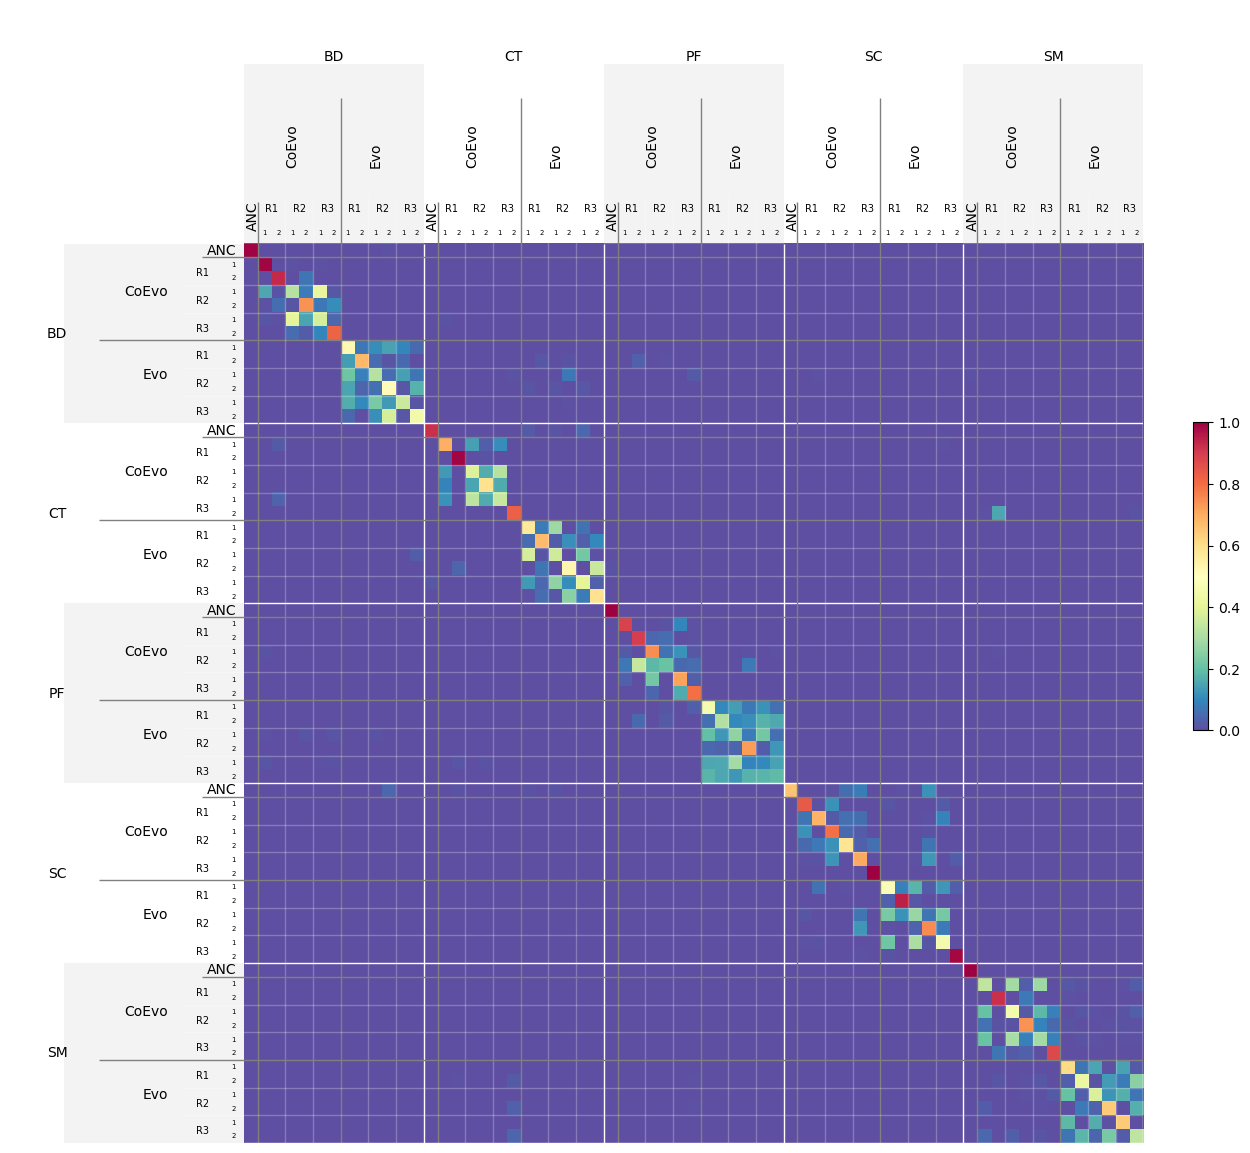

In [22]:
annotations = sorted(np.unique(rf_labels))

plt.figure(figsize=(16, 16), dpi=100)
plt.imshow(cm_norm, cmap="Spectral_r")

species, species_counts = np.unique(np.array([x.split("_")[0] for x in annotations]), return_counts=True)
prev = 0
for i in range(len(species)):
    
     # Species labels and lines
    species_label_spacer = -14
    plt.text(species_label_spacer, prev+int(species_counts[i]/2), species[i], ha="center", va="center")
    plt.text(prev+int(species_counts[i]/2), species_label_spacer, species[i], ha="center", va="center")
    plt.vlines(prev+species_counts[i]-0.5, -0.5, len(annotations)-0.5, color="white", lw=1)
    
    plt.hlines(prev+species_counts[i]-0.5, -0.5, len(annotations)-0.5, color="white", lw=1)

    # plt.text(history_label_spacer, prev+int(species_counts[i]/4), "ANC", ha="right", va="center", fontsize=10)
    
    # History labels and lines
    
    history_label_spacer = -6
    history_labels = ["CoEvo", "Evo"]
    for j in range(2):
        plt.text(history_label_spacer, prev+int(species_counts[i]/4)+int(species_counts[i]/2)*j, history_labels[j%2], ha="right", va="center", fontsize=10)
        plt.text(prev+int(species_counts[i]/4)+int(species_counts[i]/2)*j, history_label_spacer, history_labels[j%2], ha="center", va="bottom", rotation=90, fontsize=10)

    plt.vlines(prev+1-0.5, -3.5, len(annotations)-0.5, color="grey", lw=1)
    plt.vlines(prev+int(species_counts[i]/2)+0.5, -11, len(annotations)-0.5, color="grey", lw=1)
    plt.hlines(prev+1-0.5, -3.5, len(annotations)-0.5, color="grey", lw=1)
    plt.hlines(prev+int(species_counts[i]/2)+0.5, -11, len(annotations)-0.5, color="grey", lw=1)
    
    
    # Replicate labels and lines
    replicate_label_spacer = -3
    replicate_labels = ["R1", "R2", "R3"]
    
    plt.text(1+prev-0.85, -2.5, "ANC", ha="center", va="center", rotation=90, fontsize=10)
    plt.text(-1, 1+prev-1, "ANC", ha="right", va="center", rotation=0, fontsize=10)
    for j in range(6):
        plt.text(replicate_label_spacer, 1+prev+int(species_counts[i]/12)+int(species_counts[i]/6)*j, replicate_labels[j%3], ha="right", va="bottom", fontsize=7)
        plt.text(1+prev+int(species_counts[i]/12)+int(species_counts[i]/6)*j, replicate_label_spacer, replicate_labels[j%3], ha="right", va="center", fontsize=7)

    
    for j in [1, 2, 4, 5]:
        plt.vlines(1+prev+int(species_counts[i]/6)*j-0.5, -4, len(annotations)-0.5, color="white", lw=1, alpha=0.25)
        plt.hlines(1+prev+int(species_counts[i]/6)*j-0.5, -5, len(annotations)-0.5, color="white", lw=1, alpha=0.25)

    
    # Time point labels

    tp_label_spacer = -1.25
    tp_labels = ["1", "2"]
    for j in range(12):
        plt.text(tp_label_spacer, 1+prev+int(species_counts[i]/12)*j, tp_labels[j%2], va="center", ha="center", fontsize=5)
        plt.text(1+prev+int(species_counts[i]/12)*j, tp_label_spacer, tp_labels[j%2], va="center", ha="center", fontsize=5)


    prev += species_counts[i]
    
    
ax = plt.gca()

for j in range(len(species)):
    if j % 2 == 0:
        ax.add_patch(plt.Rectangle((-0.5+13*j, -0.5), 13, -13, facecolor='lightgrey', alpha=0.25, clip_on=False, linewidth = 0))
        ax.add_patch(plt.Rectangle((-0.5, -0.5+13*j), -13, 13, facecolor='lightgrey', alpha=0.25, clip_on=False, linewidth = 0))

plt.colorbar(fraction=0.046, pad=0.04, shrink=0.25)
plt.axis('off')
plt.show()

## Replicate classification accuracy

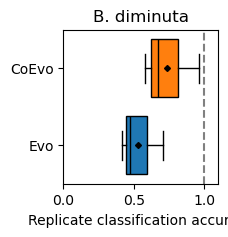

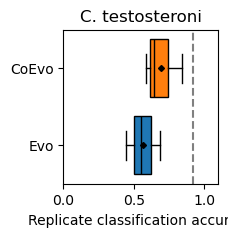

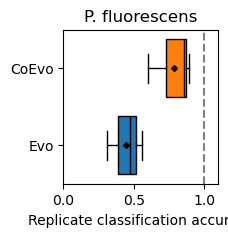

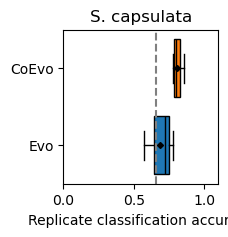

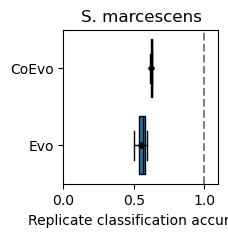

In [23]:
species_names = ["B. diminuta", "C. testosteroni", "P. fluorescens", "S. capsulata", "S. marcescens"]
for i in range(5):
    species_tm = cm[i*13:(i+1)*13, i*13:(i+1)*13]

    anc_tm = species_tm[0, 0]
    coevo_tm = species_tm[1:7, 1:7]
    evo_tm = species_tm[7:, 7:]
    
    coevo_r1_tm = coevo_tm[:2, :2]
    coevo_r2_tm = coevo_tm[2:4, 2:4]
    coevo_r3_tm = coevo_tm[4:, 4:]
    
    evo_r1_tm = evo_tm[:2, :2]
    evo_r2_tm = evo_tm[2:4, 2:4]
    evo_r3_tm = evo_tm[4:, 4:]
    
    coevo_rep_tms = [coevo_r1_tm, coevo_r2_tm, coevo_r3_tm]
    evo_rep_tms = [evo_r1_tm, evo_r2_tm, evo_r3_tm]

    anc_acc = anc_tm/200
    
    coevo_r_accs = []
    for rep_tm in coevo_rep_tms:
        coevo_r_accs.append(np.sum(rep_tm)/1000)
    
    evo_r_accs = []
    for rep_tm in evo_rep_tms:
        evo_r_accs.append(np.sum(rep_tm)/1000)
    
    plt.figure(figsize=(2, 2))
    for bp, accs, color in [(1, coevo_r_accs, "tab:orange"), (0, evo_r_accs, "tab:blue")]:
        box = plt.boxplot(accs, positions=[bp], widths=[0.75], patch_artist=True, vert=False, showmeans=True, meanprops={"markerfacecolor": "black", "markeredgecolor": "black", "marker": "D", "ms": 3}, medianprops={"color": "black"})
        box['boxes'][0].set_facecolor(color)
        # plt.scatter([bp-0.025, bp, bp+0.025], accs, facecolors='none', edgecolors='k')

    plt.yticks([0, 1], ["Evo", "CoEvo"])
    plt.xlim(0, 1.1)
    plt.vlines(anc_acc, plt.ylim()[0], plt.ylim()[1], linestyle="dashed", color="grey")
    plt.title(species_names[i])
    plt.xlabel("Replicate classification accuracy")
    plt.show()